# Data Understanding

In this notebook, we will perform initial data understanding and visualizations to understand the dataset better.  

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 🧹 Data Processing Overview

This notebook standardizes the entire data-processing workflow for both **Daily Data** and **Hourly Data**, ensuring clarity, consistency, and maintainability.

## 🎯 Objectives
- Clean and structure raw data using a unified logic.
- Handle missing values consistently across both datasets.
- Detect and cap outliers using the IQR method.
- Apply appropriate scaling (RobustScaler) for numeric features.
- Encode categorical features using OneHotEncoder.
- Export fully processed datasets ready for modeling.

## 🔧 Standardized Workflow
1.  **Load Dataset**
2.  **Data Summary: Missing & Dtypes**
3.  **Drop columns with excessive missing values**
4.  **Identify numeric / categorical / datetime columns**
5.  **Outlier capping (IQR)**
6.  **Imputation (Iterative for numeric / most_frequent for categorical)**
7.  **Encoding**
8.  **Save processed outputs**

This structure is applied consistently to both the daily and hourly datasets.

**I. Data Dictionary**

| Variable name        | Role       | Type        | Group         | Range of values                              | Demographic | **Description (Fully Written)**                                                                                                                                                                                                                                                                                                                                                           |
| -------------------- | ---------- | ----------- | ------------- | -------------------------------------------- | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`name`**             | Identifier | Categorical | –             | Hanoi                                        | Geographic  | This variable identifies the specific weather station or geographical location where the atmospheric measurements were recorded. It helps track the provenance of the data, differentiate between measurement sources, and ensure consistency across stations. Although not directly used as a predictive feature, it is essential for data validation and station-based quality control. |
| **`datetime`**         | Feature    | Datetime    | –             | 2015-01-01 → 2025-10-01                      | Time        | This variable represents the exact calendar date of each daily weather observation. It is used to order the dataset chronologically, align features with their corresponding targets, generate time-based attributes (such as month or day-of-year), and ensure proper time-series modeling without data leakage.                                                                         |
| **`tempmax`**          | Feature    | Numeric     | Temperature   | 8.0 → 41.9 °C                                | Climate     | The maximum air temperature measured during the day. It describes daytime heating intensity and is commonly used to identify heatwaves, estimate daily temperature range, and support derived variables such as diurnal variation or evaporative demand.                                                                                                                                  |
| **`tempmin`**          | Feature    | Numeric     | Temperature   | 5.9 → 31.0 °C                                | Climate     | The minimum air temperature recorded during nighttime. It helps characterize nocturnal cooling, identify cold events, and calculate daily temperature amplitude. The value supports temperature-range-based derived features.                                                                                                                                                             |
| **`temp`**             | **Target** | Numeric     | Temperature   | 7.0 → 35.5 °C                                | Climate     | The average air temperature for the entire day. This is the primary target variable for prediction, representing the overall thermal condition of each day and serving as a central indicator in statistical and machine-learning models.                                                                                                                                                 |
| **`feelslikemax`**     | Feature    | Numeric     | Temperature   | 8.0 → 52.5 °C                                | Climate     | The maximum perceived temperature, adjusted for humidity and wind effects. It reflects the level of thermal stress experienced by humans and is a more realistic descriptor of extreme heat than the raw air temperature.                                                                                                                                                                 |
| **`feelslikemin`**     | Feature    | Numeric     | Temperature   | 2.1 → 40.4 °C                                | Climate     | The minimum daily “feels-like” temperature. This variable describes nighttime discomfort levels by incorporating both air temperature and meteorological modifiers such as humidity and wind speed.                                                                                                                                                                                       |
| **`feelslike`**        | Feature    | Numeric     | Temperature   | 4.6 → 46.2 °C                                | Climate     | The daily average perceived temperature, representing how warm or cold conditions actually felt to humans. It integrates humidity, radiation, and wind effects, providing a better measure of thermal comfort than a simple temperature average.                                                                                                                                          |
| **`dew`**              | Feature    | Numeric     | Humidity      | −2.0 → 28.5 °C                               | Atmospheric | The dew point temperature, indicating the threshold at which water vapor begins to condense. It is a direct measure of atmospheric moisture content and strongly influences fog formation, perceived humidity, and thermal comfort.                                                                                                                                                       |
| **`humidity`**         | Feature    | Numeric     | Humidity      | 31 → 100 %                                   | Atmospheric | The relative humidity expressed as a percentage, representing how much moisture the air contains compared to its maximum capacity. This variable affects cloud formation, precipitation likelihood, and human comfort, and plays a significant role in many derived meteorological indicators.                                                                                            |
| **`precip`**           | Feature    | Numeric     | Precipitation | 0.0 → 333.117 mm                             | Atmospheric | The total precipitation accumulated during the day. It includes rainfall and the melted equivalent of frozen precipitation. High values often signal severe weather events, while long periods of zero precipitation indicate dry spells.                                                                                                                                                 |
| **`precipprob`**       | Feature    | Numeric     | Precipitation | 0 → 100 %                                    | Atmospheric | The probability that measurable precipitation occurred during the day. It reflects forecast-based or model-derived likelihood of rain or snow and is often used to support classification of wet versus dry conditions.                                                                                                                                                                   |
| **`precipcover`**      | Feature    | Numeric     | Precipitation | 0 → 100 %                                    | Atmospheric | The percentage of the day during which precipitation was observed. Unlike total precipitation, this variable measures duration rather than amount, helping differentiate between brief storms and prolonged rainfall.                                                                                                                                                                     |
| **`preciptype`**       | Feature    | Categorical | Precipitation | “rain”                                       | Atmospheric | The categorical description of the type of precipitation. Although the dataset contains only “rain,” this variable provides structural compatibility with regions where snow, sleet, or mixed precipitation types exist.                                                                                                                                                                  |
| **`snow`**             | Feature    | Numeric     | Precipitation | 0 → 0                                        | Atmospheric | The daily snowfall amount measured in millimeters. All values are zero for Hanoi, reflecting the region’s tropical climate; however, the variable is retained for completeness and compatibility with multi-regional datasets.                                                                                                                                                            |
| **`snowdepth`**        | Feature    | Numeric     | Precipitation | 0 → 0                                        | Atmospheric | The depth of accumulated snow on the ground. Similar to the snow variable, it remains zero throughout the dataset but is preserved for structural consistency.                                                                                                                                                                                                                            |
| **`windgust`**         | Feature    | Numeric     | Wind          | 7.2 → 118.8 km/h                             | Atmospheric | The maximum instantaneous wind speed (gust) observed during the day. It is an important indicator of storm intensity, local turbulence, and hazardous weather conditions such as squalls or thunderstorms.                                                                                                                                                                                |
| **`windspeed`**        | Feature    | Numeric     | Wind          | 6.5 → 53.6 km/h                              | Atmospheric | The average sustained wind speed throughout the day. It influences heat exchange at the surface, evaporation rates, and comfort levels, and is often used to compute wind vectors or wind-related interaction features.                                                                                                                                                                   |
| **`winddir`**          | Feature    | Numeric     | Wind          | 0 → 359.8°                                   | Atmospheric | The average direction of the wind measured in degrees. This circular variable describes the prevailing wind orientation and is frequently transformed using sine and cosine to avoid directional discontinuity at 0°/360°.                                                                                                                                                                |
| **`sealevelpressure`** | Feature    | Numeric     | Pressure      | 991.1 → 1037.2 hPa                           | Atmospheric | The atmospheric pressure reduced to sea level, providing a standardized measurement for identifying high- and low-pressure systems. Changes in this variable reveal frontal passages, storm development, or stable weather regimes.                                                                                                                                                       |
| **`cloudcover`**       | Feature    | Numeric     | Cloud/Sky     | 0 → 100 %                                    | Atmospheric | The percentage of the sky obscured by clouds. It modulates solar radiation reaching the surface and is a critical factor in temperature forecasting, as high cloud cover typically reduces cooling at night and limits daytime heating.                                                                                                                                                   |
| **`visibility`**       | Feature    | Numeric     | Cloud/Sky     | 2.4 → 12.6 km                                | Atmospheric | The horizontal visibility distance measured during the day. Reduced visibility often signals the presence of fog, haze, or heavy precipitation events, making it a valuable indicator of hazardous atmospheric conditions.                                                                                                                                                                |
| **`solarradiation`**   | Feature    | Numeric     | Solar         | 0 → 323.5 W/m²                               | Atmospheric | The average incoming solar radiation at the surface. It directly influences surface heating, evaporation, and energy-balance processes, making it essential for both temperature modeling and solar-energy assessment.                                                                                                                                                                    |
| **`solarenergy`**      | Feature    | Numeric     | Solar         | 0 → 27.9 MJ/m²                               | Atmospheric | The total amount of solar energy received during the day, calculated as the time-integrated value of solar radiation. It reflects the cumulative heating potential and seasonal sunlight availability.                                                                                                                                                                                    |
| **`uvindex`**          | Feature    | Numeric     | Solar         | 0 → 10                                       | Atmospheric | The maximum daily ultraviolet radiation index, indicating the level of potentially harmful UV exposure. While not directly tied to temperature, it correlates with clear skies and solar intensity.                                                                                                                                                                                       |
| **`severerisk`**       | Feature    | Numeric     | Weather Risk  | 5 → 100                                      | Atmospheric | A composite risk score estimating the likelihood of severe weather events. It may incorporate multiple atmospheric variables and is often incomplete or noisy, requiring careful preprocessing before being used in predictive modeling.                                                                                                                                                  |
| **`sunrise`**          | Feature    | Datetime    | Time          | ~06:33 → ~06:50                              | Time        | The local time of sunrise. It is mainly used to calculate daylight duration and to track seasonal changes in solar exposure throughout the year.                                                                                                                                                                                                                                          |
| **`sunset`**           | Feature    | Datetime    | Time          | ~17:26 → ~18:46                              | Time        | The local sunset time, paired with sunrise to determine the total amount of daylight available. Its variation provides a clear measure of seasonal progression.                                                                                                                                                                                                                           |
| **`moonphase`**        | Feature    | Numeric     | Lunar         | 0 → 0.98                                     | Time        | The fraction representing the illuminated portion of the Moon. Although it has minimal direct meteorological impact, it can be useful for long-term seasonal or night-illumination analyses.                                                                                                                                                                                              |
| **`conditions`**       | Feature    | Categorical | Summary       | Clear, Overcast, Rain, Partially Cloudy      | Atmospheric | A concise textual summary describing the dominant weather condition of the day. It categorizes atmospheric states into easily recognizable groups and is often encoded into binary flags or multi-label variables for use in machine learning.                                                                                                                                            |
| **`description`**      | Feature    | Text        | Summary       | Example: “Partly cloudy throughout the day.” | Atmospheric | A detailed human-written description of the day’s weather, typically containing richer information than the categorical conditions variable. It may include timing of rainfall, cloud evolution, or notable atmospheric events, and can be processed to extract keywords or sentiment-like weather indicators.                                                                            |
| **`icon`**             | Feature    | Categorical | Visual        | clear-day, partly-cloudy-day, rain, cloudy   | Atmospheric | A symbolic representation of the daily weather condition used mainly for visual interfaces. It offers a compact way to encode weather categories and often parallels the “conditions” variable.                                                                                                                                                                                           |
| **`stations`**         | Feature    | Categorical | Source        | Station IDs (48820099999, VVNB, etc.)        | Data Source | A list of weather stations contributing to the observation. It identifies the measurement sources, helps assess reliability and spatial coverage, and supports data cleaning in cases where different stations show inconsistencies.                                                                                                                                                      |


## DATA HANOI DAILY

**I. Basic EDA**

In [60]:
# Load the dataset
df_daily = pd.read_excel(r"../../data/raw/hanoi_daily.xlsx")
print("Shape of data:", df_daily.shape)
df_daily.head()

Shape of data: (3927, 33)


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Hanoi,2015-01-01,24.0,11.4,17.7,24.0,11.4,17.7,9.4,63.8,0.0,0,0.0,NaN,0,0,25.2,13.0,78.3,1023.4,0.4,7.2,197.4,17.1,7,NaN,2015-01-01T06:33:34,2015-01-01T17:26:18,0.36,Clear,Clear conditions throughout the day.,clear-day,"48820099999,48823099999,48825099999,4883109999..."
1,Hanoi,2015-01-02,22.0,11.0,16.3,22.0,11.0,16.3,9.4,65.6,0.0,0,0.0,NaN,0,0,23.4,13.9,99.8,1022.7,28.3,7.7,187.6,16.2,7,NaN,2015-01-02T06:33:53,2015-01-02T17:26:56,0.39,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48820099999,48823099999,48825099999,4883109999..."
2,Hanoi,2015-01-03,21.0,13.1,17.0,21.0,13.1,17.0,12.4,75.6,0.0,0,0.0,NaN,0,0,21.6,13.0,97.0,1020.0,42.0,6.0,115.5,9.9,4,NaN,2015-01-03T06:34:11,2015-01-03T17:27:34,0.43,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48820099999,48823099999,48825099999,4883109999..."
3,Hanoi,2015-01-04,22.6,16.9,19.3,22.6,16.9,19.3,16.1,82.0,0.6,100,25.0,rain,0,0,25.2,17.2,98.7,1013.5,88.0,6.3,64.3,5.6,3,NaN,2015-01-04T06:34:28,2015-01-04T17:28:12,0.46,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"48820099999,48823099999,48825099999,4883109999..."
4,Hanoi,2015-01-05,23.0,18.5,20.4,23.0,18.5,20.4,18.4,88.4,0.0,0,0.0,NaN,0,0,19.1,13.0,85.7,1011.2,90.6,4.2,93.7,7.9,4,NaN,2015-01-05T06:34:44,2015-01-05T17:28:51,0.50,Overcast,Cloudy skies throughout the day.,cloudy,"48820099999,48823099999,48825099999,4883109999..."


In [61]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3927 non-null   object 
 1   datetime          3927 non-null   object 
 2   tempmax           3927 non-null   float64
 3   tempmin           3927 non-null   float64
 4   temp              3927 non-null   float64
 5   feelslikemax      3927 non-null   float64
 6   feelslikemin      3927 non-null   float64
 7   feelslike         3927 non-null   float64
 8   dew               3927 non-null   float64
 9   humidity          3927 non-null   float64
 10  precip            3927 non-null   float64
 11  precipprob        3927 non-null   int64  
 12  precipcover       3927 non-null   float64
 13  preciptype        2885 non-null   object 
 14  snow              3927 non-null   int64  
 15  snowdepth         3927 non-null   int64  
 16  windgust          3927 non-null   float64


In [62]:
# Check categorical-like columns
for col in df_daily.select_dtypes(include='object').columns:
    print(f"{col}: {df_daily[col].nunique()} unique values")

name: 1 unique values
datetime: 3927 unique values
preciptype: 1 unique values
sunrise: 3927 unique values
sunset: 3927 unique values
conditions: 6 unique values
description: 36 unique values
icon: 4 unique values
stations: 32 unique values


The check shows that most string columns either have very few or a very large number of unique values:
- **`name`** and **`preciptype`** each contain only **1 unique value** → constant columns, providing no analytical variance, so we should drop them. 

- **`conditions` (6 values)** and **`icon` (4 values)** clearly represent **categorical variables** describing weather states.  

- **`description` (36 values)** and **`stations` (32 values)** have a **moderate number of unique values** - they can still be treated as categorical if used for grouping or filtering, though `description` is closer to free-text.  

- **`datetime`, `sunrise`, and `sunset`** have **3927 unique values each**, meaning they are **unique per observation** and should remain as `datetime`, not categorical.

Overall, only `conditions` and `icon` are clearly categorical; `description` and `stations` may be semi-categorical, while the rest are identifiers or time-based columns.

**II. Diagnosing and correcting data types**

In [63]:
# Diagnosing and correcting data types
# 1.Datetime column
datetime_cols = ['datetime', 'sunrise', 'sunset']
for col in datetime_cols:
    df_daily[col] = pd.to_datetime(df_daily[col], errors='coerce')
    
# 2 precipprob → float64
df_daily['precipprob'] = df_daily['precipprob'].astype('float64')

# 3. Change to Categorical features
categorical_cols = ['conditions', 'description', 'icon', 'uvindex']
df_daily[categorical_cols] = df_daily[categorical_cols].astype('category')

# 4. Drop 4 columns do not have the values for modeling
df_daily.drop(columns=['name', 'preciptype','snow', 'snowdepth'], inplace=True)

print(df_daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          3927 non-null   datetime64[ns]
 1   tempmax           3927 non-null   float64       
 2   tempmin           3927 non-null   float64       
 3   temp              3927 non-null   float64       
 4   feelslikemax      3927 non-null   float64       
 5   feelslikemin      3927 non-null   float64       
 6   feelslike         3927 non-null   float64       
 7   dew               3927 non-null   float64       
 8   humidity          3927 non-null   float64       
 9   precip            3927 non-null   float64       
 10  precipprob        3927 non-null   float64       
 11  precipcover       3927 non-null   float64       
 12  windgust          3927 non-null   float64       
 13  windspeed         3927 non-null   float64       
 14  winddir           3927 n

At this step, we reviewed each column to make sure the data types truly match the meaning of the variables.
- Transform some datetime columns into datetime64 data type.
- **`precipprob`** was changed from `int64` to `float64`, since this column represents the **probability of precipitation (%)**, which in theory can have decimal values. Keeping it as a float makes the data more accurate for later analysis.

- We also converted a few text-based columns —  
  **`conditions`, `description`, `icon`, and `uvindex`** — into the `category` type.  
  These are not continuous values but rather **qualitative labels** (e.g., weather condition, UV level). Converting them helps Pandas handle the data more efficiently and keeps the dataset semantically correct.

- Drop two cloumns contain only one unique value: **`name`**, **`preciptype`**.

- The columns **`snow`** and **`snowdepth`** were removed entirely.  
  They contain only zeros throughout all records, which makes sense for Hanoi’s tropical monsoon climate - it never snows here. Keeping them would only add noise and waste memory.

After these adjustments, the DataFrame (`df_daily`) now feels much “cleaner”: every column has a type that fits its real-world meaning, and the dataset is lighter and ready for further analysis.

In [64]:
df_daily.describe()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,severerisk,sunrise,sunset,moonphase
count,3927,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.00000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,3927.000000,1361.000000,3927,3927,3927.000000
mean,2020-05-17 00:00:00,28.515152,21.934963,24.898370,32.620550,22.703107,27.397021,20.488541,78.27344,5.226019,72.167049,8.221225,27.022587,17.394423,126.961268,1011.085358,63.828928,8.605602,155.118386,13.388719,28.518736,2020-05-17 05:51:52.353450496,2020-05-17 18:01:52.471352064,0.483990
min,2015-01-01 00:00:00,8.000000,5.900000,7.000000,8.000000,2.100000,4.600000,-2.000000,31.00000,0.000000,0.000000,0.000000,7.200000,6.500000,0.000000,991.100000,0.000000,2.400000,0.000000,0.000000,5.000000,2015-01-01 06:33:34,2015-01-01 17:26:18,0.000000
25%,2017-09-08 12:00:00,24.100000,18.000000,21.000000,24.100000,18.000000,21.000000,16.850000,72.20000,0.000000,0.000000,0.000000,21.600000,13.900000,61.900000,1005.200000,49.350000,7.700000,91.100000,7.800000,10.000000,2017-09-08 17:42:01.500000,2017-09-09 06:05:57,0.250000
50%,2020-05-17 00:00:00,29.500000,23.000000,26.100000,32.700000,23.000000,27.100000,22.500000,79.80000,0.267000,100.000000,4.170000,25.900000,16.600000,109.300000,1010.700000,67.300000,9.000000,154.100000,13.300000,10.000000,2020-05-17 05:18:11,2020-05-17 18:28:05,0.500000
75%,2023-01-23 12:00:00,33.000000,26.000000,29.000000,41.300000,26.000000,33.900000,25.200000,85.80000,2.595000,100.000000,12.500000,31.000000,20.500000,131.900000,1016.500000,82.300000,9.800000,216.600000,18.700000,60.000000,2023-01-23 18:35:47.500000,2023-01-24 05:41:19,0.750000
max,2025-10-01 00:00:00,41.900000,31.000000,35.500000,52.500000,40.400000,46.200000,28.500000,100.00000,333.117000,100.000000,100.000000,118.800000,53.600000,359.800000,1037.200000,100.000000,12.600000,323.500000,27.900000,100.000000,2025-10-01 05:47:40,2025-10-01 17:44:44,0.980000
std,NaN,5.842098,4.870462,5.139137,9.530943,6.075115,7.734238,5.783574,10.76699,15.895322,44.823360,10.936552,8.080222,4.999515,97.746225,7.142712,23.636997,1.756703,77.239502,6.676342,24.089535,NaN,NaN,0.288759


Comments about summary statistics:
- The temperature values fit well with Hanoi’s climate, though the “feels like” temperatures peaking above 50°C seem to be outliers or from the reason about humidity.

- Precipitation is another variable that stands out — most days are dry, but a few entries show rainfall over 300 mm, which is unusually high for Hanoi, which can refer to large hurricane.

- Some probability-related columns, like `precipprob` and `precipcover`, also seem to lean toward round figures such as 100%, suggesting they might work better as categorical indicators rather than continuous percentages => drop 'precipprob'.

- Apart from that, the dataset structure is generally solid. The variable `severerisk` has too many missing values to be reliable, and columns like `name` or `preciptype` that contain only one value could be safely removed. With a bit of cleaning for these edge cases, the data should be ready for modeling => Handling missing data phase will focus on this.

In [65]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          3927 non-null   datetime64[ns]
 1   tempmax           3927 non-null   float64       
 2   tempmin           3927 non-null   float64       
 3   temp              3927 non-null   float64       
 4   feelslikemax      3927 non-null   float64       
 5   feelslikemin      3927 non-null   float64       
 6   feelslike         3927 non-null   float64       
 7   dew               3927 non-null   float64       
 8   humidity          3927 non-null   float64       
 9   precip            3927 non-null   float64       
 10  precipprob        3927 non-null   float64       
 11  precipcover       3927 non-null   float64       
 12  windgust          3927 non-null   float64       
 13  windspeed         3927 non-null   float64       
 14  winddir           3927 n

In [66]:
# Save processed data
df_daily.to_excel('../../data/processed/data_daily_after_basic_understand.xlsx', index=False)

**III. Deeper EDA**

In [67]:
data = df_daily.copy()

**A. NUMERICAL FEATURES**

**1. Target variable (Temp)**


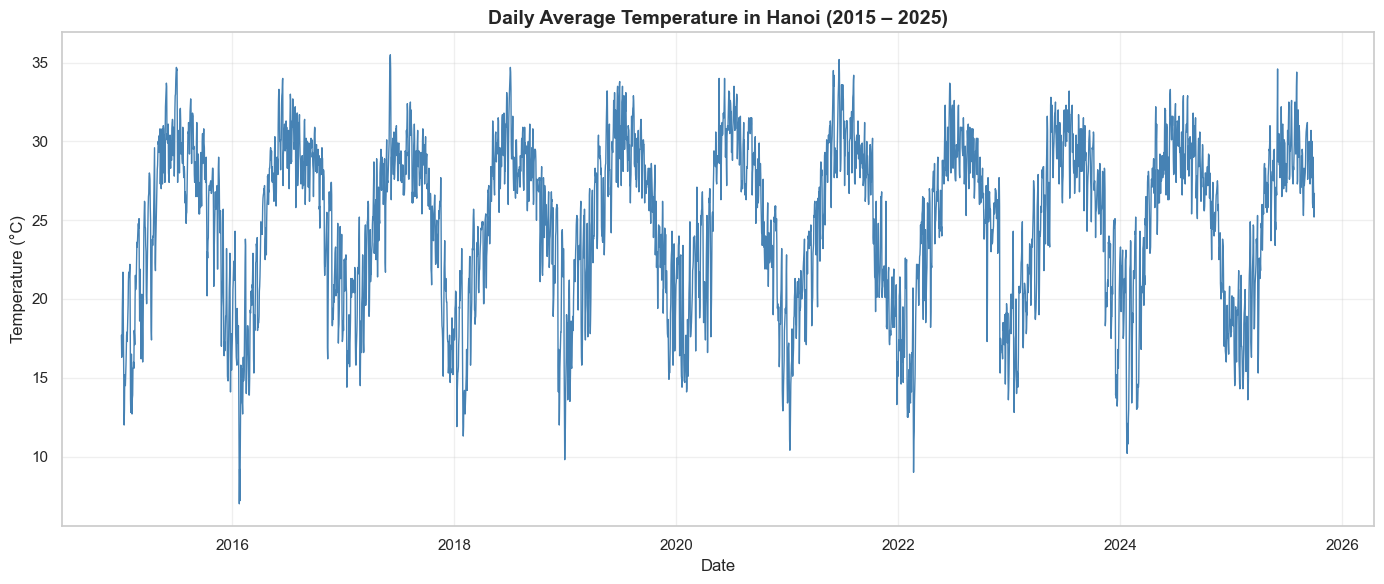

In [68]:
# Plot a line chart for the 'temp' column (target variable)
plt.figure(figsize=(14, 6))
plt.plot(data['datetime'], data['temp'], color='steelblue', linewidth=1)

# Customize display
plt.title("Daily Average Temperature in Hanoi (2015 – 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Do not display legend
plt.show()

- The temperature chart of Hanoi from 2015 to 2025 displays a strongly seasonal and rhythmic pattern, characteristic of a tropical monsoon climate. Each year follows a consistent cycle of warming from early spring, peaking during the hot summer months, and gradually cooling toward the year’s end, revealing a stable annual periodicity.

- The amplitude of fluctuation remains largely consistent, with temperatures ranging between 10°C in winter and 35°C in summer, suggesting an annual variation of about 25°C. This stability indicates that Hanoi’s overall thermal structure has been steady over the past decade, showing no clear evidence of long-term warming or cooling trends.

- Some years exhibit greater climatic extremes than others. Noticeable cold spells occur in 2016, 2021, 2022, and 2024, while 2017 and 2021 mark exceptionally hot summers exceeding 35°C. In contrast, 2018–2019 and 2023 appear relatively mild, with smoother transitions between seasons. Such interannual variability may be associated with fluctuations in monsoon intensity or regional climatic anomalies.

- Overall, the graph illustrates a predictable yet dynamic climate rhythm. Despite occasional extremes, the temperature pattern remains stable and cyclical, reflecting the resilience of Hanoi’s monsoon-driven climate and its well-balanced alternation between heat and coolness across the four seasons.

**2. Temperature group (temp, tempmax, tempmin, feelslike, feelslikemax, feelslikemin)**

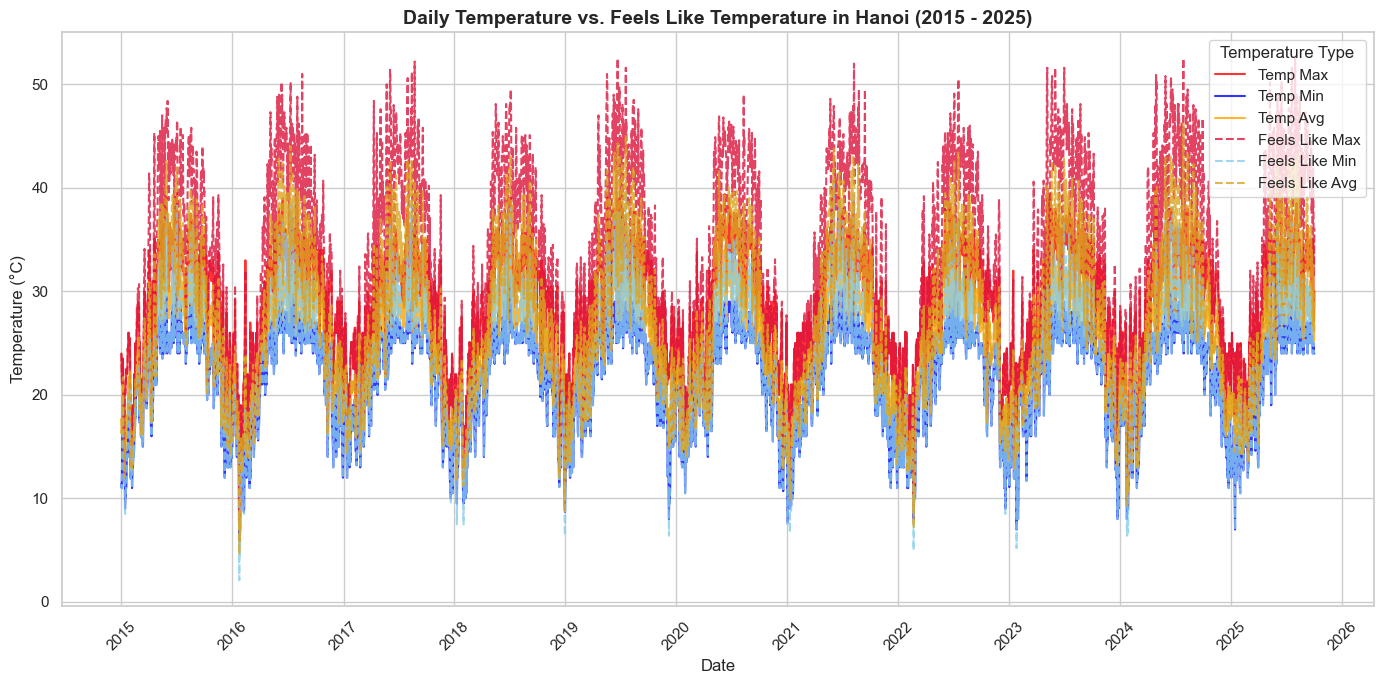

In [69]:
plt.figure(figsize=(14, 7))

sns.lineplot(x='datetime', y='tempmax', data=data, label='Temp Max', color='red', alpha=0.8)
sns.lineplot(x='datetime', y='tempmin', data=data, label='Temp Min', color='blue', alpha=0.8)
sns.lineplot(x='datetime', y='temp', data=data, label='Temp Avg', color='orange', alpha=0.8)

sns.lineplot(x='datetime', y='feelslikemax', data=data, label='Feels Like Max', linestyle='--', color='crimson', alpha=0.8)
sns.lineplot(x='datetime', y='feelslikemin', data=data, label='Feels Like Min', linestyle='--', color='skyblue', alpha=0.8)
sns.lineplot(x='datetime', y='feelslike', data=data, label='Feels Like Avg', linestyle='--', color='goldenrod', alpha=0.8)

plt.title('Daily Temperature vs. Feels Like Temperature in Hanoi (2015 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())      
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))

plt.xticks(rotation=45)
plt.tight_layout()

plt.legend(title='Temperature Type', loc='upper right')
plt.show()


- Temperatures in Hanoi have a clear seasonal cycle, with peaks in summer (May–August) and troughs in winter (December–February).

- The “Feels Like” curve is roughly parallel and coincides with the actual temperature curve, showing a small difference, but is still slightly higher in summer — possibly due to high humidity and the hotter effect.

- The amplitude of fluctuations (the difference between tempmax and tempmin) is larger in the transition months (March–April and September–October), indicating erratic weather.

- Overall, the correlation between actual and felt temperatures is strongly linear, suggesting that the feelslike and temp variables can be combined in the feature engineering step or one of the two can be chosen to represent this group.

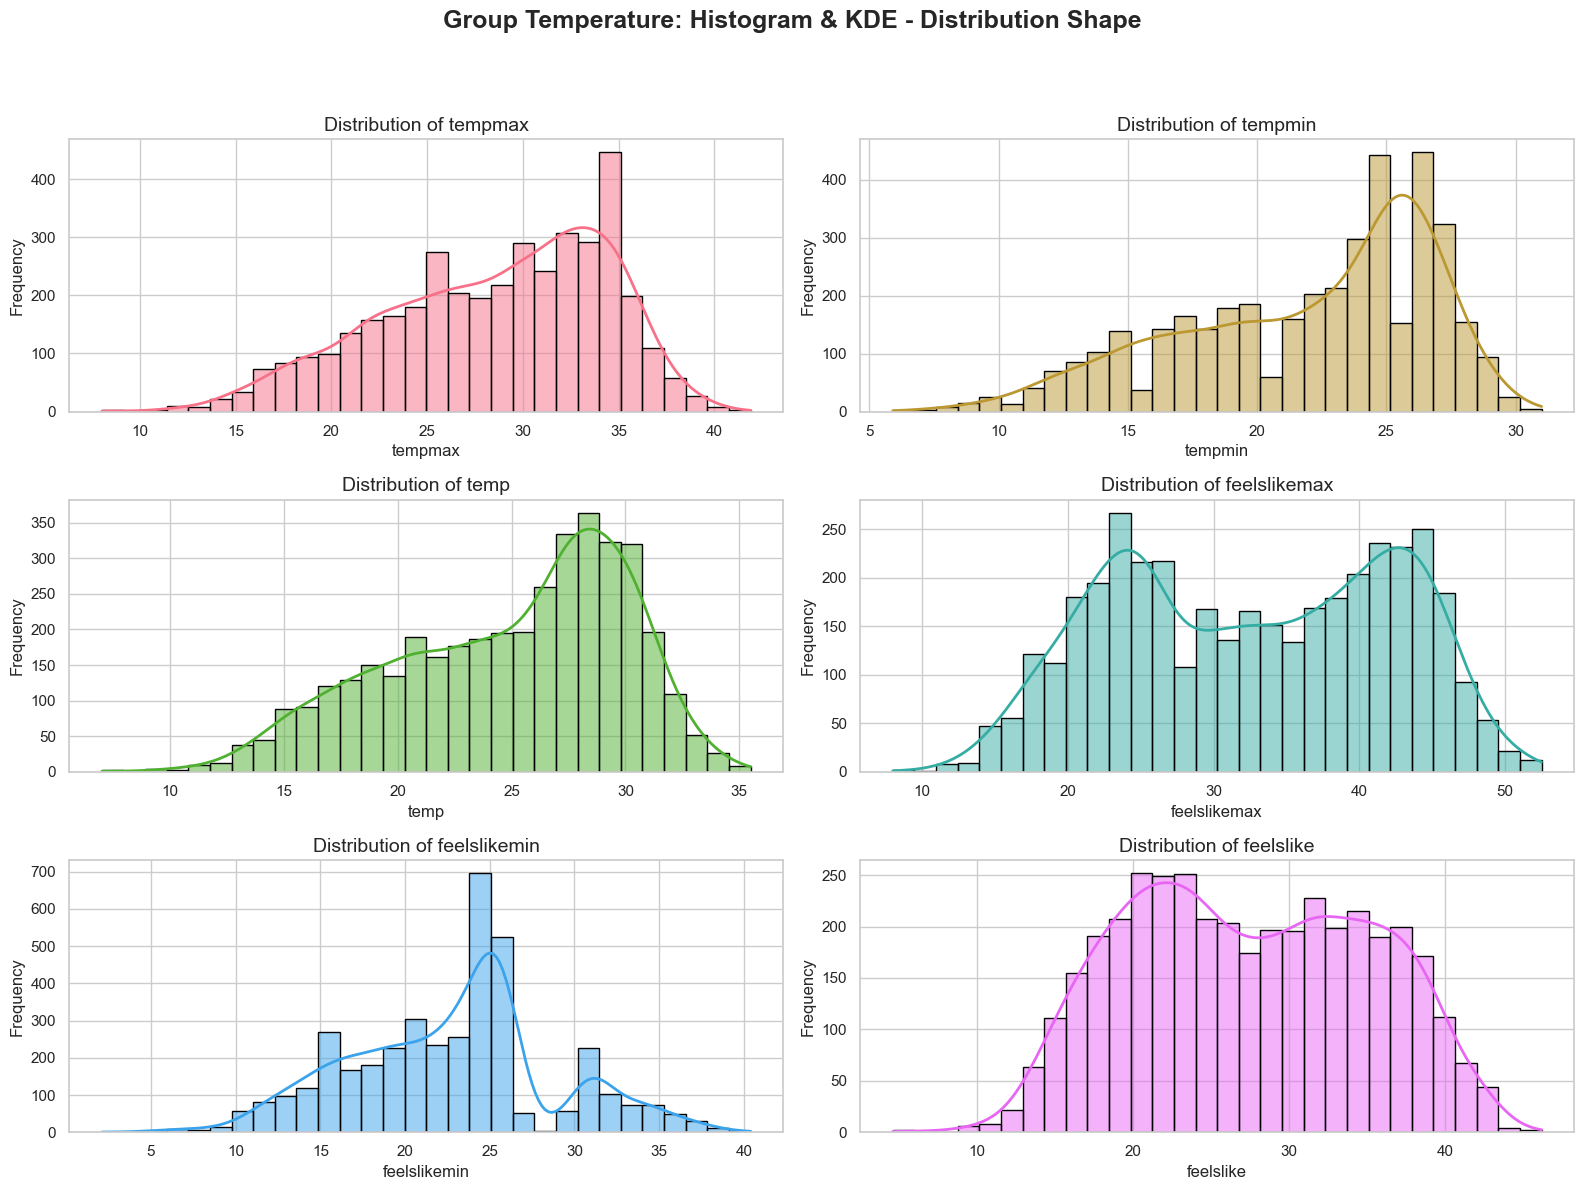

In [70]:
group_name = 'Temperature'
features = ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike']

n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

# Define a distinct color palette (husl) with a color for each feature
colors = sns.color_palette("husl", n_colors=n_features)

plt.rcParams['figure.figsize'] = (16, 4 * n_rows)

fig_hist, axes_hist = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
fig_hist.suptitle(f'Group {group_name}: Histogram & KDE - Distribution Shape', 
                  fontsize=18, fontweight='bold', y=1.02)
axes_hist = axes_hist.flatten() 

for i, col in enumerate(features):
    if col in data.columns:
        # Use colors[i] to assign a unique color for each plot
        sns.histplot(
            data=data, 
            x=col, 
            kde=True, 
            ax=axes_hist[i], 
            color=colors[i],       # Assign color from palette
            edgecolor='black', 
            bins=30, 
            line_kws={'lw': 2, 'color': 'black'}  # KDE line in black for contrast
        )
        axes_hist[i].set_title(f'Distribution of {col}', fontsize=14)
        axes_hist[i].set_ylabel('Frequency', fontsize=12)

# Remove any empty subplots
for j in range(i + 1, n_rows * n_cols):
    if j < len(axes_hist):
        fig_hist.delaxes(axes_hist[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

1. Actual Temperature Distribution ($tempmax$, $tempmin$, $temp$)

The analysis reveals clear distinctions in the distribution shape based on the type of temperature metric:

- **Average Temperature ($temp$):** This variable is the **most symmetrical**, closely resembling a normal (unimodal) distribution, with frequency strongly concentrated in the $25^\circ C$ to $30^\circ C$ range.

- **Maximum Temperature ($tempmax$):** This variable is **negatively (left) skewed**. The majority of observations are clustered in the warmer range, primarily between $32^\circ C$ and $35^\circ C$.

- **Minimum Temperature ($tempmin$):** Conversely, $tempmin$ is **strongly positively (right) skewed**. The main frequency peak lies between $22^\circ C$ and $26^\circ C$, indicating that lower minimum temperatures are recorded more often.

2. Perceived Temperature Distribution ($feelslikemax$, $feelslikemin$, $feelslike$)

The perceived "feels like" temperature variables exhibit complex, often **multi-modal** distributions, confirming that human sensation is influenced by factors beyond mere air temperature:

- **Maximum Perceived Temperature ($feelslikemax$):** This variable has a distinct **bimodal** distribution. The first peak is found around $20^\circ C - 25^\circ C$ (mild/pleasant days), and a more prominent second peak is situated around $40^\circ C - 45^\circ C$ (hot/stifling days).

- **Average Perceived Temperature ($feelslike$):** This also exhibits a **bimodal** distribution, with high-frequency clusters centered around $20^\circ C - 25^\circ C$ and another group around $28^\circ C - 32^\circ C$.

- **Minimum Perceived Temperature ($feelslikemin$):** While still strongly right-skewed, this variable displays an **unusual secondary peak** near $30^\circ C$. This suggests that high humidity or other factors can cause even the daily minimum temperature to be perceived as significantly warmer than the actual measurement.

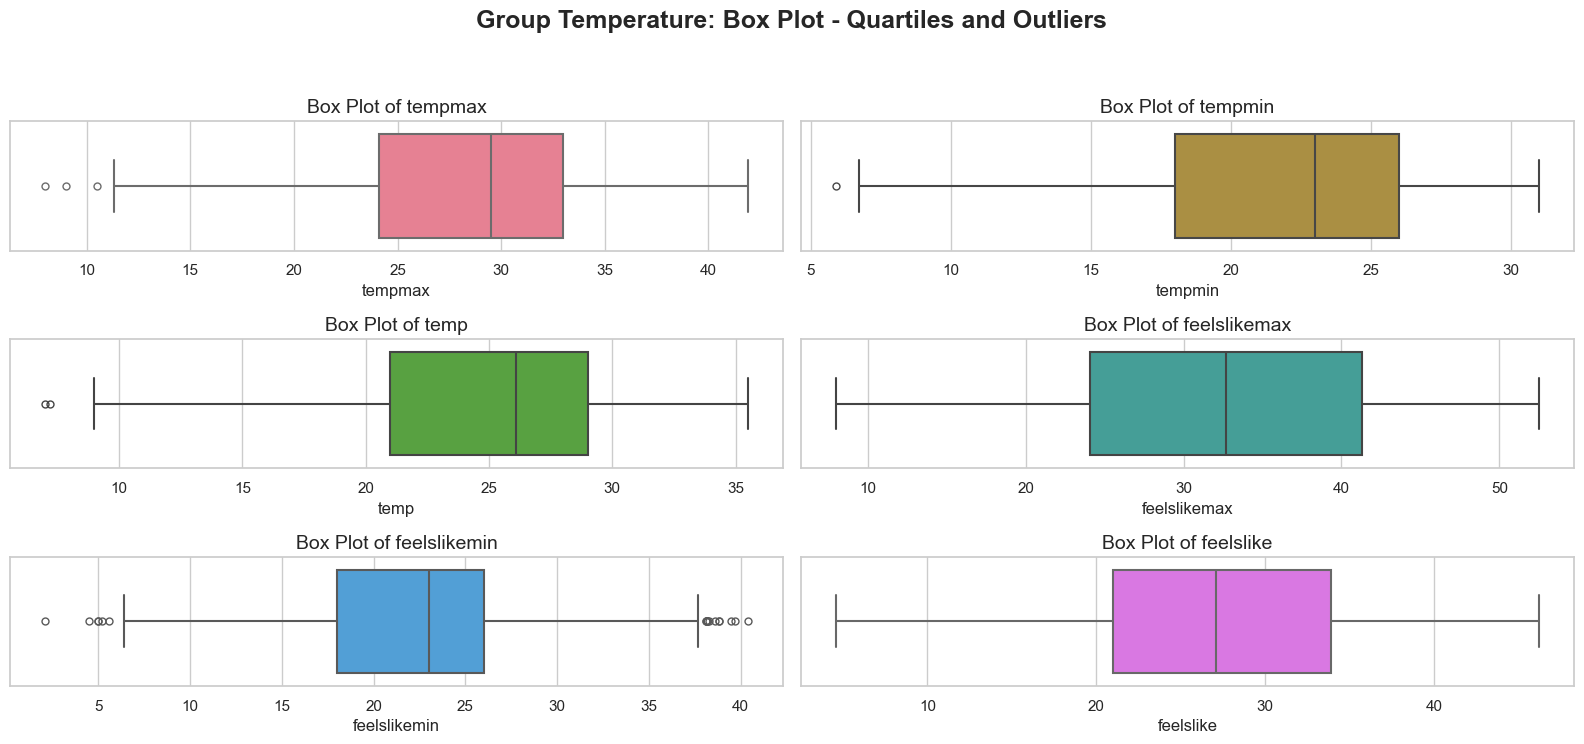

In [71]:
colors = sns.color_palette('husl', n_colors=n_features)

fig_box, axes_box = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
fig_box.suptitle(f'Group {group_name}: Box Plot - Quartiles and Outliers', 
                 fontsize=18, fontweight='bold', y=1.02)
axes_box = axes_box.flatten() 

for i, col in enumerate(features):
    if col in data.columns:
        sns.boxplot(data=data, x=col, ax=axes_box[i], 
                    color=colors[i],
                    orient='h', fliersize=5, linewidth=1.5)
        axes_box[i].set_title(f'Box Plot of {col}', fontsize=14)
        axes_box[i].set_ylabel('')

# Ẩn các ô trống còn lại
for j in range(i + 1, n_rows * n_cols):
    if j < len(axes_box):
        fig_box.delaxes(axes_box[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

1. Actual Temperature Variables (Temp, Tempmin, Tempmax):

The actual temperature metrics show expected deviations based on their definition:

- **Average Temperature (`temp`):** Exhibits the **highest degree of symmetry**, with the median closely aligned with the center of the interquartile range (IQR), spanning roughly $23^\circ C$ to $29^\circ C$. It displays outliers primarily at very low temperatures.

- **Minimum Temperature (`tempmin`):** Shows a mildly **positive (right) skew**, as the median is slightly shifted toward the lower values. The distribution is concentrated between $18^\circ C$ and $26^\circ C$.

- **Maximum Temperature (`tempmax`):** Conversely, displays a **negative (left) skew**, with the median shifted toward the higher values. Its IQR is wide (approx. $25^\circ C$ to $32^\circ C$), but outliers are observed at the low end of the maximum temperature scale.

2. Feels Like Temperature Variables (Feelslike, Feelslikemin, Feelslikemax):

The "Feels Like" group generally exhibits greater variability, emphasizing the role of humidity and wind chill:

- **Maximum Perception (`feelslikemax`):** Demonstrates the **widest Interquartile Range** (IQR $\approx 25^\circ C$ to $40^\circ C$), indicating the greatest variability in the perception of extreme heat. Its distribution within the box appears relatively symmetric.

- **Average Perception (`feelslike`):** Shows good internal symmetry, with the median situated near the center of the distribution.

- **Minimum Perception (`feelslikemin`):** This is the most volatile variable. Despite a centered median, it exhibits the **highest number of outliers at both the lower and upper extremes**. This distribution suggests that the perceived minimum temperature is the most susceptible to rare, sudden fluctuations driven by composite factors (like wind chill combined with low dew point).

**3. Humidity group (humidity, dew)**

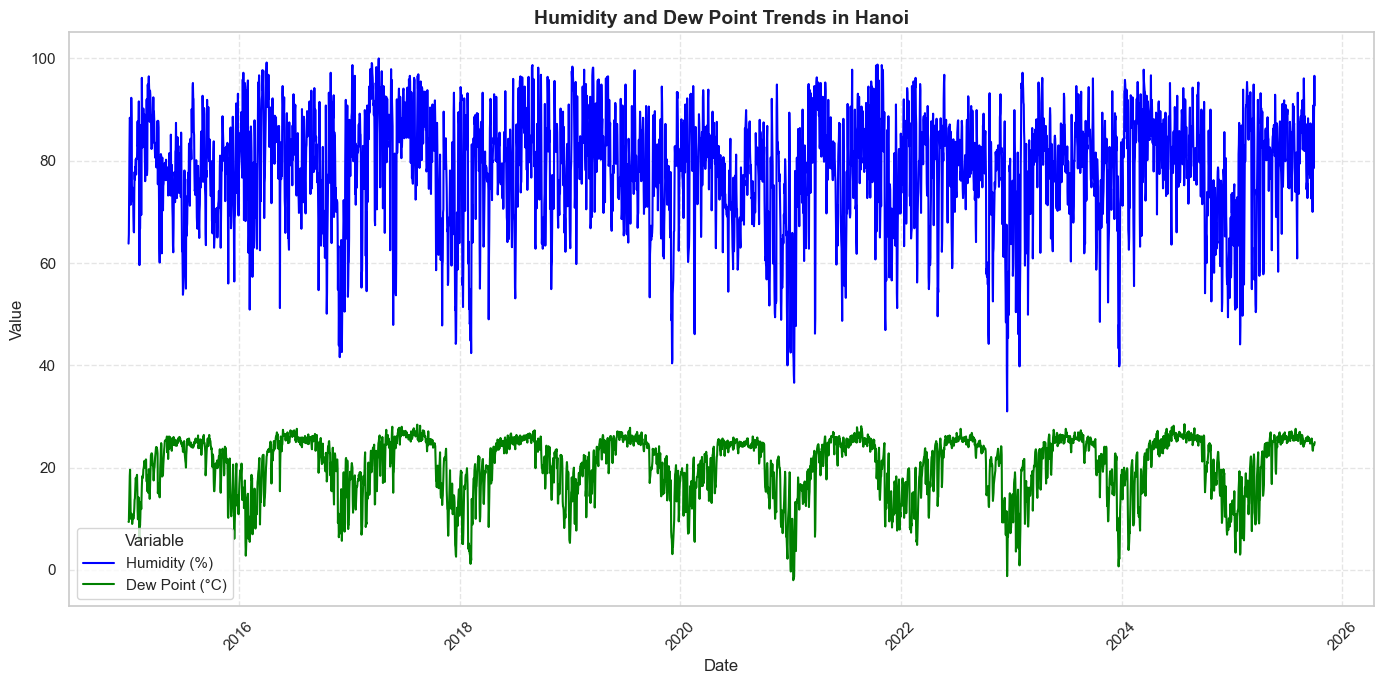

In [72]:
plt.figure(figsize=(14, 7))

sns.lineplot(x='datetime', y='humidity', data=df_daily, label='Humidity (%)', color='blue')
sns.lineplot(x='datetime', y='dew', data=df_daily, label='Dew Point (°C)', color='green')

plt.title('Humidity and Dew Point Trends in Hanoi', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(title='Variable')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Humidity remains high year-round, mostly between 70% and 90%, with occasional drops below 50%. There are frequent short-term spikes and dips, indicating rapid weather changes typical of a humid subtropical climate.

- Dew point follows a strong annual cycle, peaking around 25–27°C during summer and dropping to 5–10°C in winter. This pattern reflects Hanoi’s clear seasonal differences—hot, humid summers and cooler, drier winters.

- The dew point and humidity generally move in the same direction, meaning when one rises, the other tends to increase as well. However, humidity fluctuates more sharply, while dew point changes more smoothly across the seasons.

- Overall, both humidity and dew point show consistent seasonal fluctuations throughout the years. Hanoi maintains a consistently humid climate with clear seasonal dew point variations.

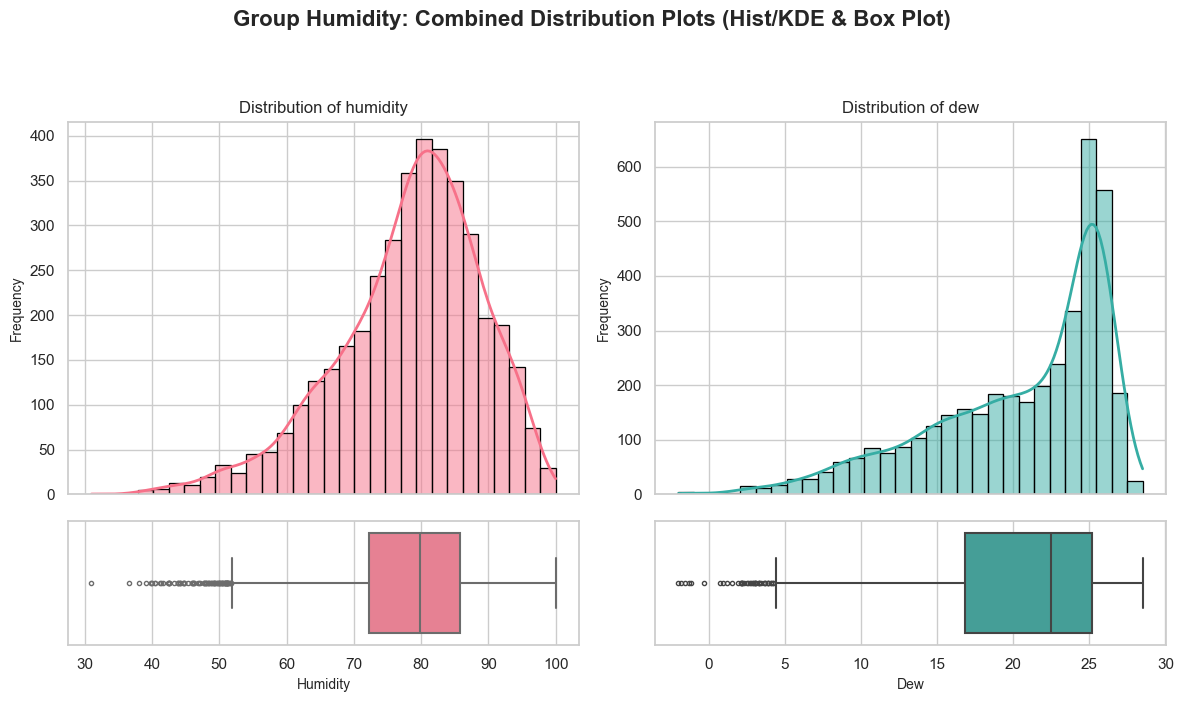

In [73]:
group_name = 'Humidity'
features = ['humidity', 'dew']

n_cols = len(features)
n_rows = 2

colors = sns.color_palette("husl", n_colors=n_cols)

fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(6 * n_cols, 7), 
                         sharex='col', # Share X-axis limits across columns (vertical stack)
                         gridspec_kw={'height_ratios': [3, 1]})

fig.suptitle(f'Group {group_name}: Combined Distribution Plots (Hist/KDE & Box Plot)', 
             fontsize=16, fontweight='bold', y=1.03)

for i, col in enumerate(features):
    # Top Row: Histogram/KDE
    # Use distinct color for bar, and a single color (black) for KDE line for contrast
    sns.histplot(data=data, x=col, kde=True, ax=axes[0, i], 
                 color=colors[i], # Distinct color
                 edgecolor='black', bins=30, line_kws={'lw': 2, 'color': 'black'}) 
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_ylabel('Frequency', fontsize=10)
    axes[0, i].set_xlabel('') 

    # Bottom Row: Box Plot
    # Use the same distinct color for consistency with the histogram above
    sns.boxplot(data=data, x=col, ax=axes[1, i], 
                color=colors[i], # Distinct color
                orient='h', fliersize=3, linewidth=1.5)
    axes[1, i].set_xlabel(col.capitalize(), fontsize=10)
    axes[1, i].set_ylabel('')
    axes[1, i].set_yticks([]) 

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

- The $Humidity$ distribution is nearly symmetric with a slight negative (left) skew, peaking strongly around $80\%-85\%$. Its Box Plot confirms high concentration within the IQR, with a few outliers observed only at the low end (very dry conditions).

- The $Dew$ (Dew Point) distribution, conversely, shows a strong positive (right) skew, with frequencies steadily rising to a high peak around $25^\circ C - 27^\circ C$. This indicates that high dew points (moist air) are the most frequent occurrences. The Box Plot displays a long tail of data and several outliers at the very low end (near $0^\circ C$), representing rare instances of extremely dry air.

- In summary: Humidity is concentrated and nearly normal, while Dew Point is heavily skewed towards high values. Both variables show that conditions of very low moisture are outliers.

**4. Precipitation group (precip, precipcover)**

- Since all two variables (`precip`, `precipcover`) are time-dependent and measured daily, **line plots** are the most suitable choice.  
They reveal when heavy rain events occur, how forecast probabilities behave seasonally, and how precipitation coverage changes throughout the year.

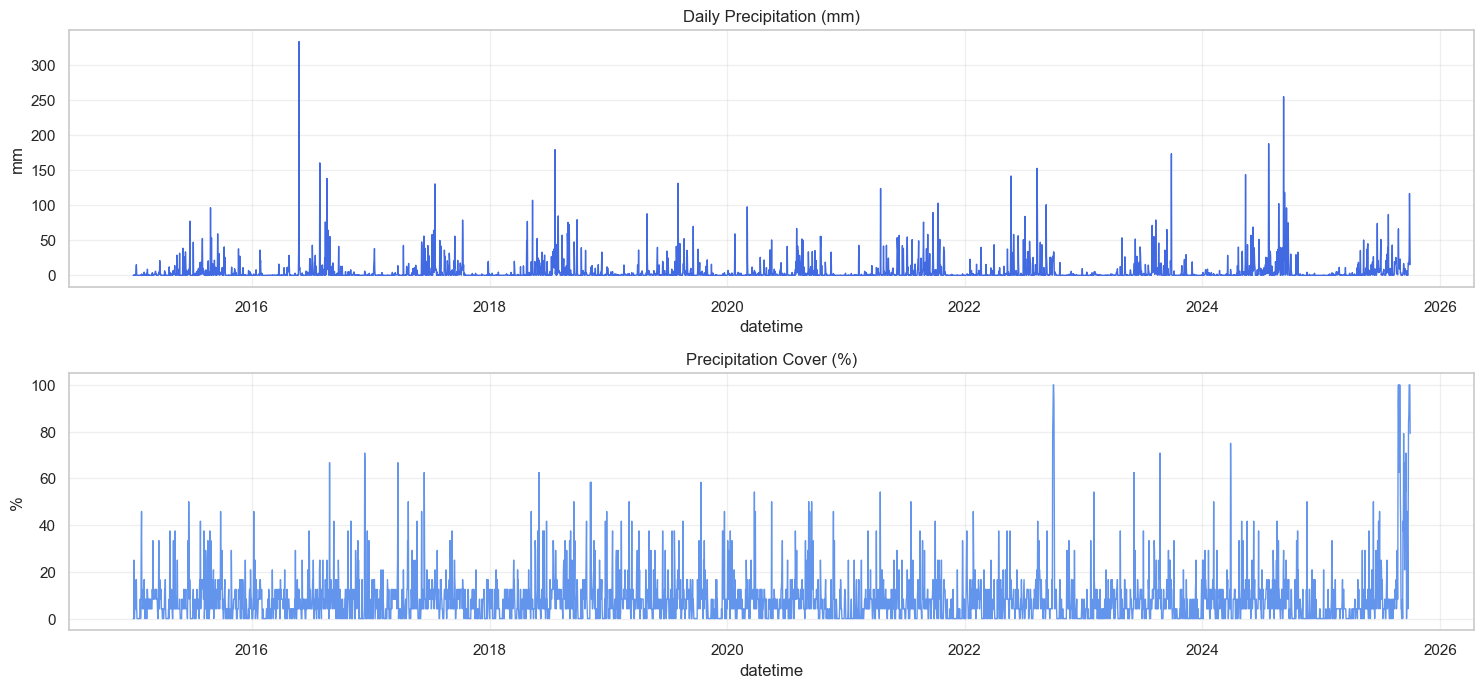

In [74]:
plt.figure(figsize=(15, 10))

# Actual precipitation
plt.subplot(3, 1, 1)
sns.lineplot(x='datetime', y='precip', data=df_daily, color='royalblue', linewidth=1)
plt.title("Daily Precipitation (mm)", fontsize=12)
plt.ylabel("mm")
plt.grid(alpha=0.3)

# Precipitation coverage
plt.subplot(3, 1, 2)
sns.lineplot(x='datetime', y='precipcover', data=df_daily, color='cornflowerblue', linewidth=1)
plt.title("Precipitation Cover (%)", fontsize=12)
plt.ylabel("%")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- The two plots show that rainfall in Hanoi is **highly seasonal**, with clear peaks during the summer monsoon (roughly May to September) and long dry stretches during the winter months.  

    + `precip` reveals sharp, irregular spikes — most days are dry, but heavy rain events occasionally exceed 100 mm/day, reflecting short, intense tropical downpours typical of the region.  

    + `precipcover`, in contrast, fluctuates more smoothly and often stays elevated over longer periods, representing days with prolonged rain or scattered showers that cover much of the day.

- From a climatic perspective, precipitation affects temperature in **two opposite ways**.  

- In the short term, rainfall cools the air by blocking sunlight and promoting evaporation — the temperature often drops during or just after a rain event.  

- However, in the following hours or days, the **humidity left behind** raises the perceived heat, making the atmosphere feel heavier and less comfortable even when measured temperatures moderate.  

- This explains why Hanoi’s rainy season can still feel oppressively hot despite frequent rainfall.

    + The **precipitation cover** plot supports this dual behavior:  
when the percentage of the day with rain is high, daytime highs tend to stay moderate due to reduced sunlight, but the lingering surface moisture traps heat near the ground at night.  

    + Conversely, when the cover remains low for many consecutive days, the air becomes drier — temperatures rise sharply in the daytime, yet the heat feels less suffocating compared to humid periods with similar readings.


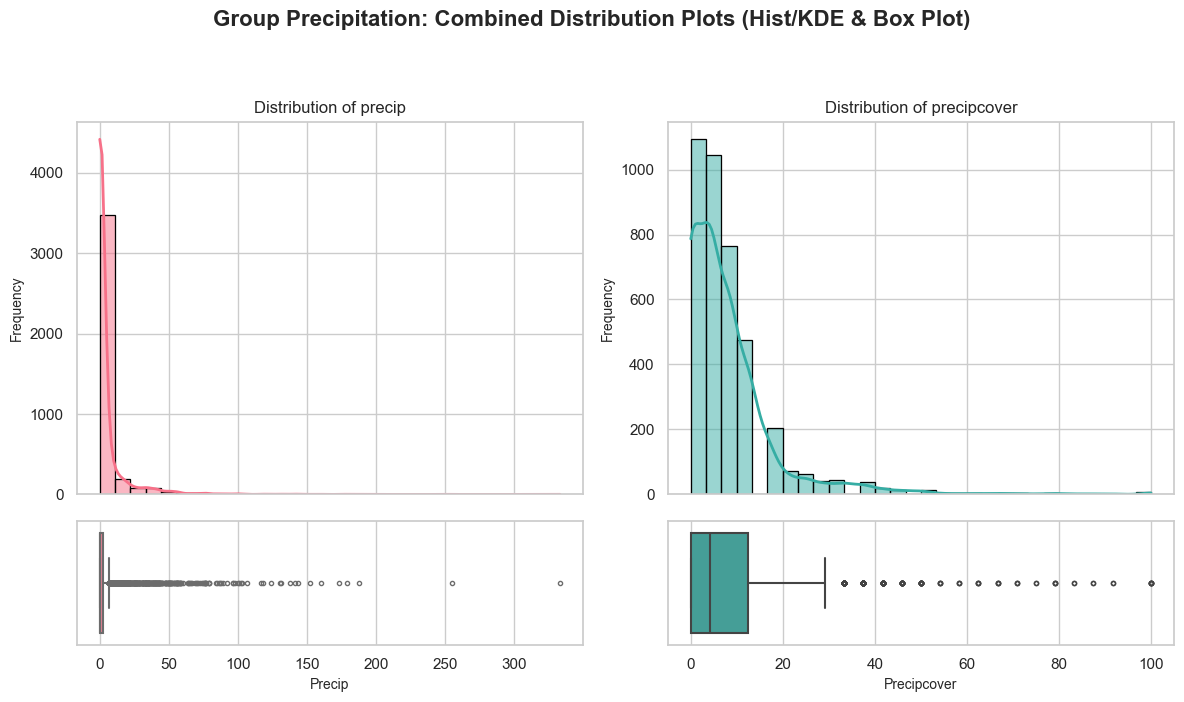

In [75]:
group_name = 'Precipitation'
features = ['precip', 'precipcover']
n_cols = len(features)
n_rows = 2

colors = sns.color_palette("husl", n_colors=n_cols)

fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(6 * n_cols, 7), 
                         sharex='col', # Share X-axis limits across columns (vertical stack)
                         gridspec_kw={'height_ratios': [3, 1]}) # Set Hist/KDE to be 3x taller than Box Plot

fig.suptitle(f'Group {group_name}: Combined Distribution Plots (Hist/KDE & Box Plot)', 
             fontsize=16, fontweight='bold', y=1.03)

for i, col in enumerate(features):
    # Top Row (Row 0): Histogram/KDE
    sns.histplot(data=data, x=col, kde=True, ax=axes[0, i], 
                 color=colors[i], # Use distinct color
                 edgecolor='black', bins=30, line_kws={'lw': 2, 'color': 'black'}) # Black KDE for contrast
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_ylabel('Frequency', fontsize=10)
    axes[0, i].set_xlabel('') 

    # Bottom Row (Row 1): Box Plot
    sns.boxplot(data=data, x=col, ax=axes[1, i], 
                color=colors[i], # Use the same distinct color
                orient='h', fliersize=3, linewidth=1.5)
    axes[1, i].set_xlabel(col.capitalize(), fontsize=10)
    axes[1, i].set_ylabel('')
    axes[1, i].set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


- Both $precip$ (Precipitation) and $precipcover$ (Precipitation Coverage) exhibit extreme positive skewness, indicating that most recorded days have little to no rainfall.

- The $precip$ distribution shows an exceptionally high peak at zero, signifying that days with zero or near-zero rainfall dominate the dataset. Its Box Plot is extremely narrow near zero and features a large number of outliers spanning the entire range, representing rare, heavy rain events.

- The $precipcover$ distribution is also highly skewed but slightly less extreme, with its mode concentrated between $0\%$ and $10\%$. Its Box Plot is slightly wider near the baseline, showing a series of outliers at high coverage levels (above $40\%$). Both variables confirm that high-value precipitation events are highly uncommon.

**5. Wind group (windgust, windspeed, winddir)**

Line plots are chosen here to highlight how wind intensity and direction change over the 10-year period.

- `windgust` shows the strongest instantaneous wind speeds (gusts),  
- `windspeed` represents the average sustained wind velocity,  
- and `winddir` gives the dominant direction of the wind flow in degrees (0° = North, 90° = East, etc.).

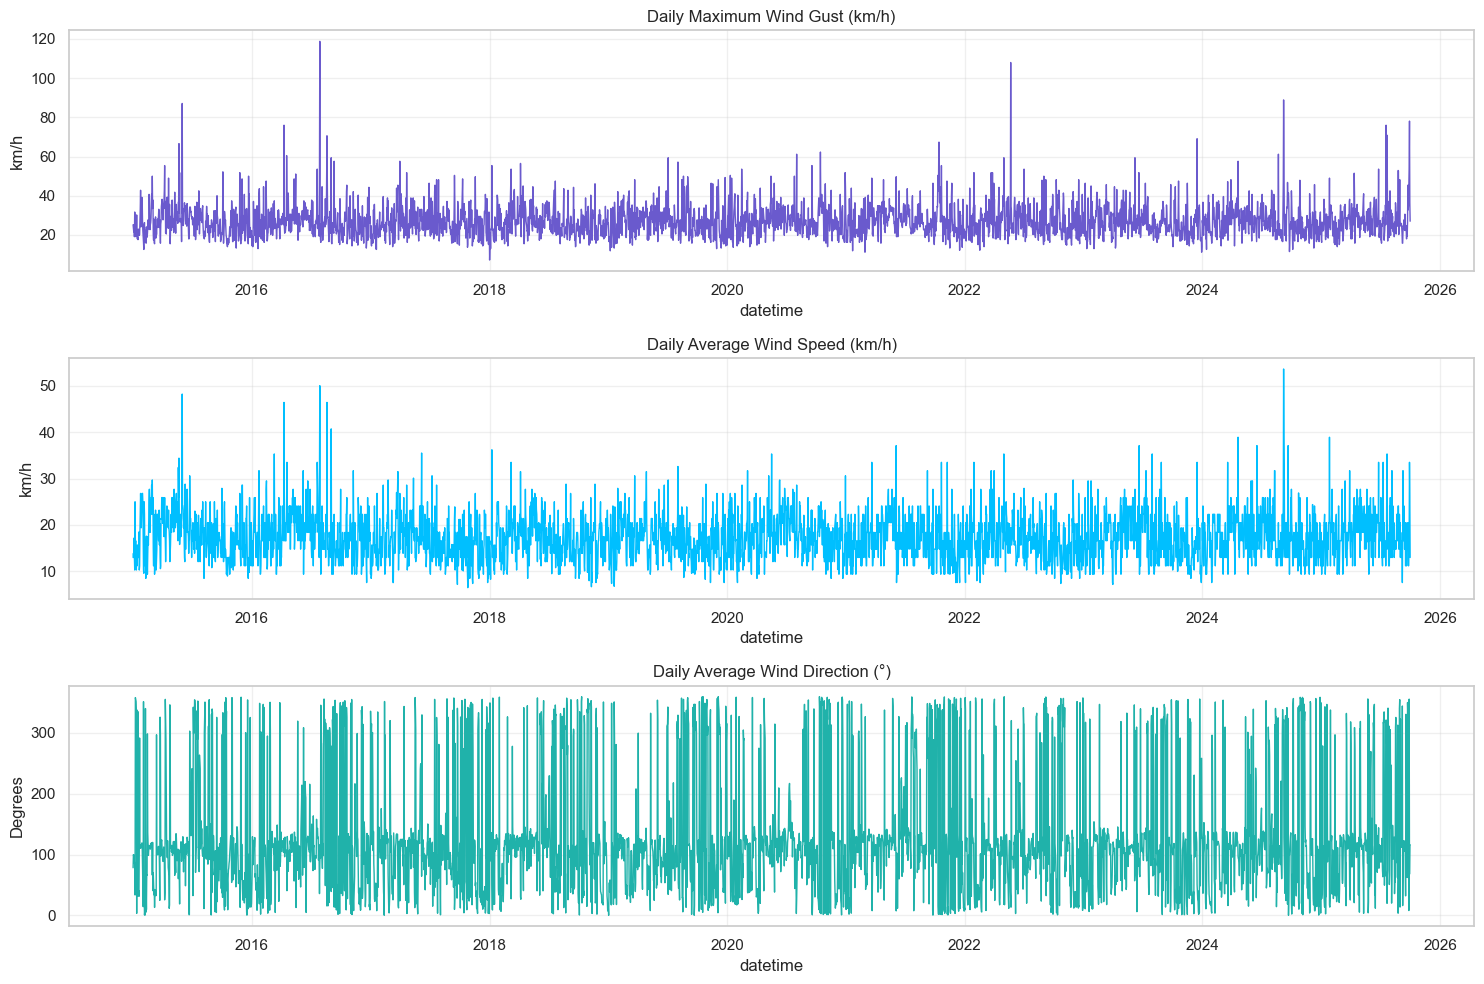

In [76]:
plt.figure(figsize=(15, 10))

# 1️⃣ Wind gusts (maximum wind speed)
plt.subplot(3, 1, 1)
sns.lineplot(x='datetime', y='windgust', data=df_daily, color='slateblue', linewidth=1)
plt.title("Daily Maximum Wind Gust (km/h)", fontsize=12)
plt.ylabel("km/h")
plt.grid(alpha=0.3)

# 2️⃣ Wind speed (average wind speed)
plt.subplot(3, 1, 2)
sns.lineplot(x='datetime', y='windspeed', data=df_daily, color='deepskyblue', linewidth=1)
plt.title("Daily Average Wind Speed (km/h)", fontsize=12)
plt.ylabel("km/h")
plt.grid(alpha=0.3)

# 3️⃣ Wind direction (average wind direction)
plt.subplot(3, 1, 3)
sns.lineplot(x='datetime', y='winddir', data=df_daily, color='lightseagreen', linewidth=1)
plt.title("Daily Average Wind Direction (°)", fontsize=12)
plt.ylabel("Degrees")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Across the decade, both `windgust` and `windspeed` show relatively stable seasonal patterns with occasional sharp peaks —  
those spikes likely correspond to **monsoon transitions or tropical storm events**, when short bursts of strong wind are recorded. The typical sustained wind speed remains moderate, while gusts occasionally exceed 80–100 km/h, especially during late summer or autumn when storms are more frequent. 

- `winddir` fluctuates widely between 0° and 360°, but some clustering around **180°–270°** (southern to western flow) may indicate the **southwest monsoon** influence in summer, while increased readings near **0°–90°** suggest **northeast monsoon** winds dominating during winter months.

- Together, these patterns depict Hanoi’s characteristic **bimodal monsoon system** — calm most of the year, punctuated by strong gusts during seasonal transitions, with the direction of prevailing winds alternating distinctly between northern and southern hemispheric flows.

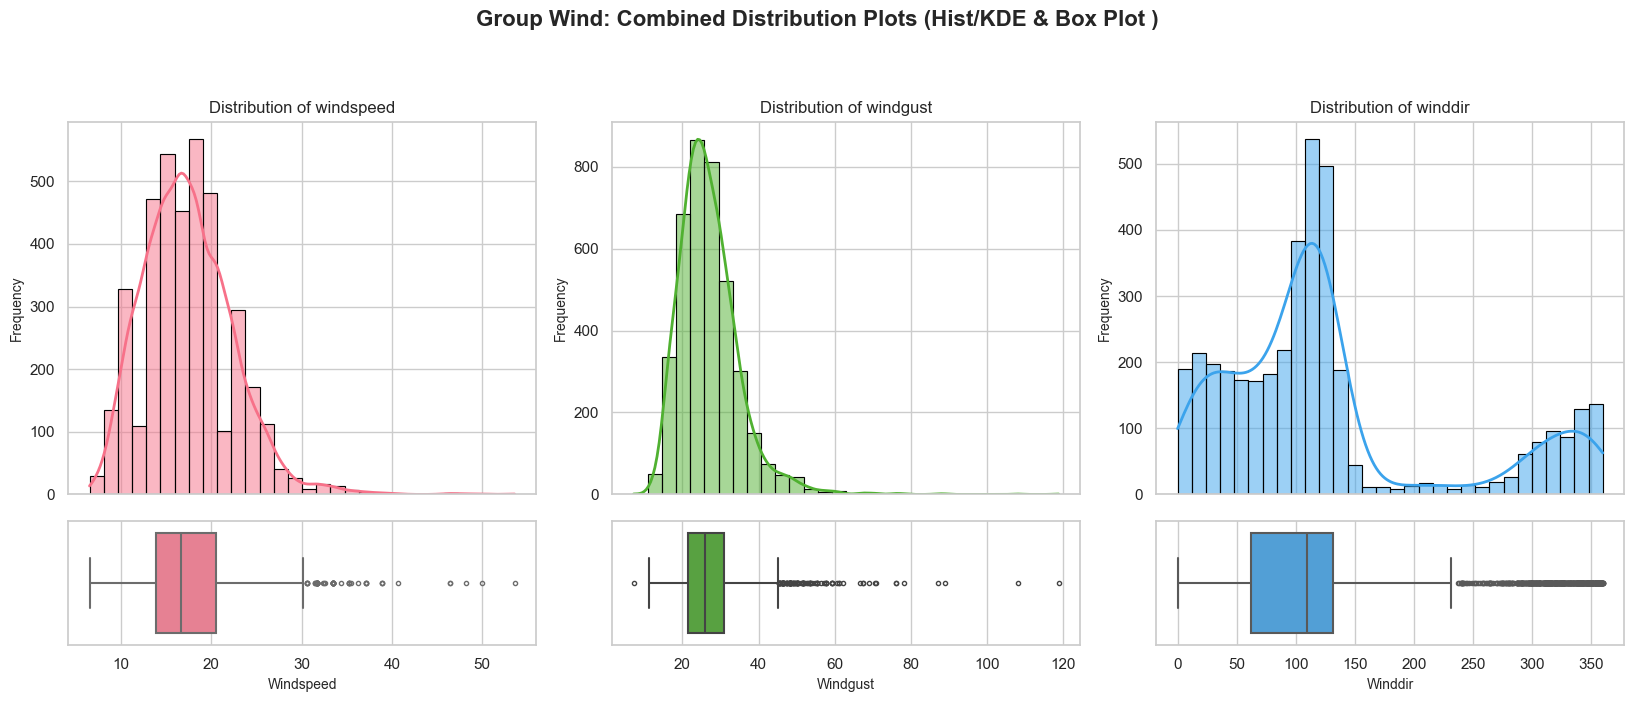

In [77]:

group_name = 'Wind'
features = ['windspeed', 'windgust', 'winddir']
n_cols = len(features)
n_rows = 2

colors = sns.color_palette("husl", n_colors=n_cols)

# Create a figure with 2 rows and n_cols columns
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(5.5 * n_cols, 7), # Adjusted size for 3x2 grid
                         sharex='col', # Share X-axis limits across columns
                         gridspec_kw={'height_ratios': [3, 1]}) # Ratio 3:1 for Hist:Box

fig.suptitle(f'Group {group_name}: Combined Distribution Plots (Hist/KDE & Box Plot )', 
             fontsize=16, fontweight='bold', y=1.03)

for i, col in enumerate(features):
    # Top Row (Row 0): Histogram/KDE
    sns.histplot(data=data, x=col, kde=True, ax=axes[0, i], 
                 color=colors[i], # Use distinct color
                 edgecolor='black', bins=30, line_kws={'lw': 2, 'color': 'black'}) # Black KDE for contrast
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_ylabel('Frequency', fontsize=10)
    axes[0, i].set_xlabel('') 

    # Bottom Row (Row 1): Box Plot
    sns.boxplot(data=data, x=col, ax=axes[1, i], 
                color=colors[i], # Use the same distinct color
                orient='h', fliersize=3, linewidth=1.5)
    axes[1, i].set_xlabel(col.capitalize(), fontsize=10)
    axes[1, i].set_ylabel('')
    axes[1, i].set_yticks([]) # Hide y-axis ticks for cleaner box plot

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


The wind speed variables exhibit a pattern of **strong positive (right) skewness**, indicating that most measurements are concentrated at low speeds, with high-speed events being rare.

- **$Windspeed$ (General Speed):** Shows a clear frequency peak primarily between **10 and 20 units**. The IQR box is relatively tight, confirming that typical daily wind speeds are moderate and stable.

- **$Windgust$ (Gust Speed):** Displays a more **extreme positive skew**, with its frequency peak occurring at very low values. This variable shows a **significant number of outliers** extending towards high speeds (up to 50 and 120 units, respectively).

- **Conclusion:** The presence of numerous high-end outliers highlights that strong wind or powerful wind gust events are rare and anomalous occurrences in the dataset.

In contrast to speed, the wind direction variable ($winddir$) displays a **complex, multimodal distribution**, indicating concentrated prevailing modes rather than a uniform spread.

- **Distribution:** The plot features a **strong primary peak** centered around **$150^\circ$** (typically Southeast direction), along with a distinct **secondary peak** approximately between **$0^\circ$ and $30^\circ$** (North).

- **Variability:** The Box Plot confirms high variability, featuring a wide IQR box that covers a large range of directions.

- **Conclusion:** The presence of multiple peaks confirms that wind direction is highly variable but tends to concentrate along several dominant directions, reflecting prevailing monsoon or local circulation patterns.

**6. Atmospheric and Solar features**

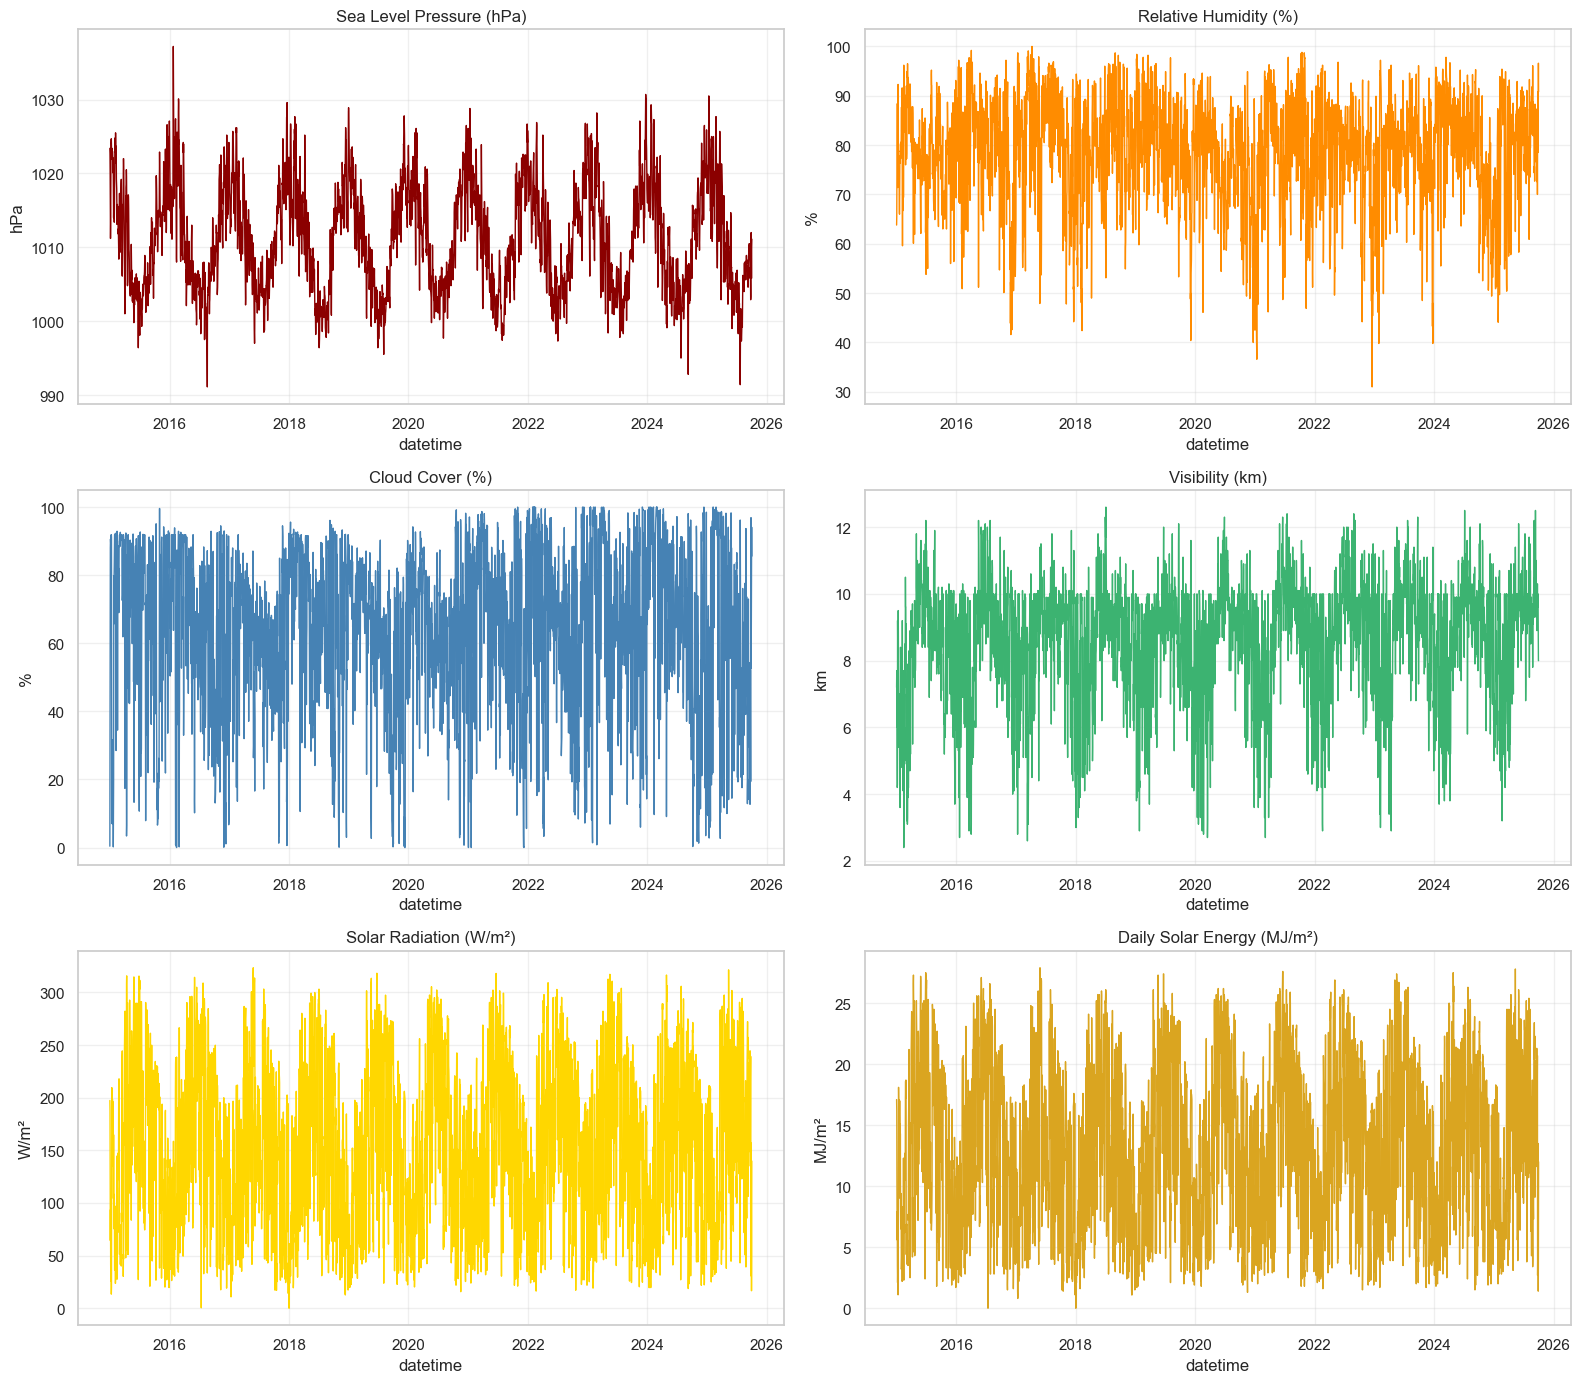

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 14))

# 1️⃣ Atmospheric pressure
plt.subplot(3, 2, 1)
sns.lineplot(x='datetime', y='sealevelpressure', data=df_daily, color='darkred', linewidth=1)
plt.title("Sea Level Pressure (hPa)")
plt.ylabel("hPa")
plt.grid(alpha=0.3)

# 2️⃣ Humidity
plt.subplot(3, 2, 2)
sns.lineplot(x='datetime', y='humidity', data=df_daily, color='darkorange', linewidth=1)
plt.title("Relative Humidity (%)")
plt.ylabel("%")
plt.grid(alpha=0.3)

# 3️⃣ Cloud cover
plt.subplot(3, 2, 3)
sns.lineplot(x='datetime', y='cloudcover', data=df_daily, color='steelblue', linewidth=1)
plt.title("Cloud Cover (%)")
plt.ylabel("%")
plt.grid(alpha=0.3)

# 4️⃣ Visibility
plt.subplot(3, 2, 4)
sns.lineplot(x='datetime', y='visibility', data=df_daily, color='mediumseagreen', linewidth=1)
plt.title("Visibility (km)")
plt.ylabel("km")
plt.grid(alpha=0.3)

# 5️⃣ Solar radiation
plt.subplot(3, 2, 5)
sns.lineplot(x='datetime', y='solarradiation', data=df_daily, color='gold', linewidth=1)
plt.title("Solar Radiation (W/m²)")
plt.ylabel("W/m²")
plt.grid(alpha=0.3)

# 6️⃣ Solar energy
plt.subplot(3, 2, 6)
sns.lineplot(x='datetime', y='solarenergy', data=df_daily, color='goldenrod', linewidth=1)
plt.title("Daily Solar Energy (MJ/m²)")
plt.ylabel("MJ/m²")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


- **Sea level pressure** stays relatively stable over the decade but oscillates gently with clear annual cycles.  
  Slight drops often coincide with stormy or hot periods — a typical pattern in tropical low-pressure systems.

- **Humidity** remains consistently high (mostly 70–90%) with stronger fluctuations in the rainy months.  
  The sharp rises during summer monsoon align with periods of frequent precipitation.

- **Cloud cover** and **solar variables** show opposite behaviors: when cloud cover peaks, solar radiation and energy fall sharply.  
  Their seasonal swing is clear — cloudy and low-radiation periods occur in summer, while clear, bright days dominate winter and spring.

- **Visibility** varies mildly but tends to decrease during humid and rainy months.  
  This is likely due to haze, fog, or rainfall reducing air clarity.

- **Solar radiation** and **solar energy** move almost in parallel, showing strong seasonality tied to daylight length and cloud presence.  
  Both peak around mid-year and drop to their lowest levels in winter.

Overall, these variables together confirm the **strong seasonal rhythm** of Hanoi’s tropical monsoon climate — high humidity, thick clouds, and lower sunlight during summer; clearer skies and more stable pressure during the cooler months.

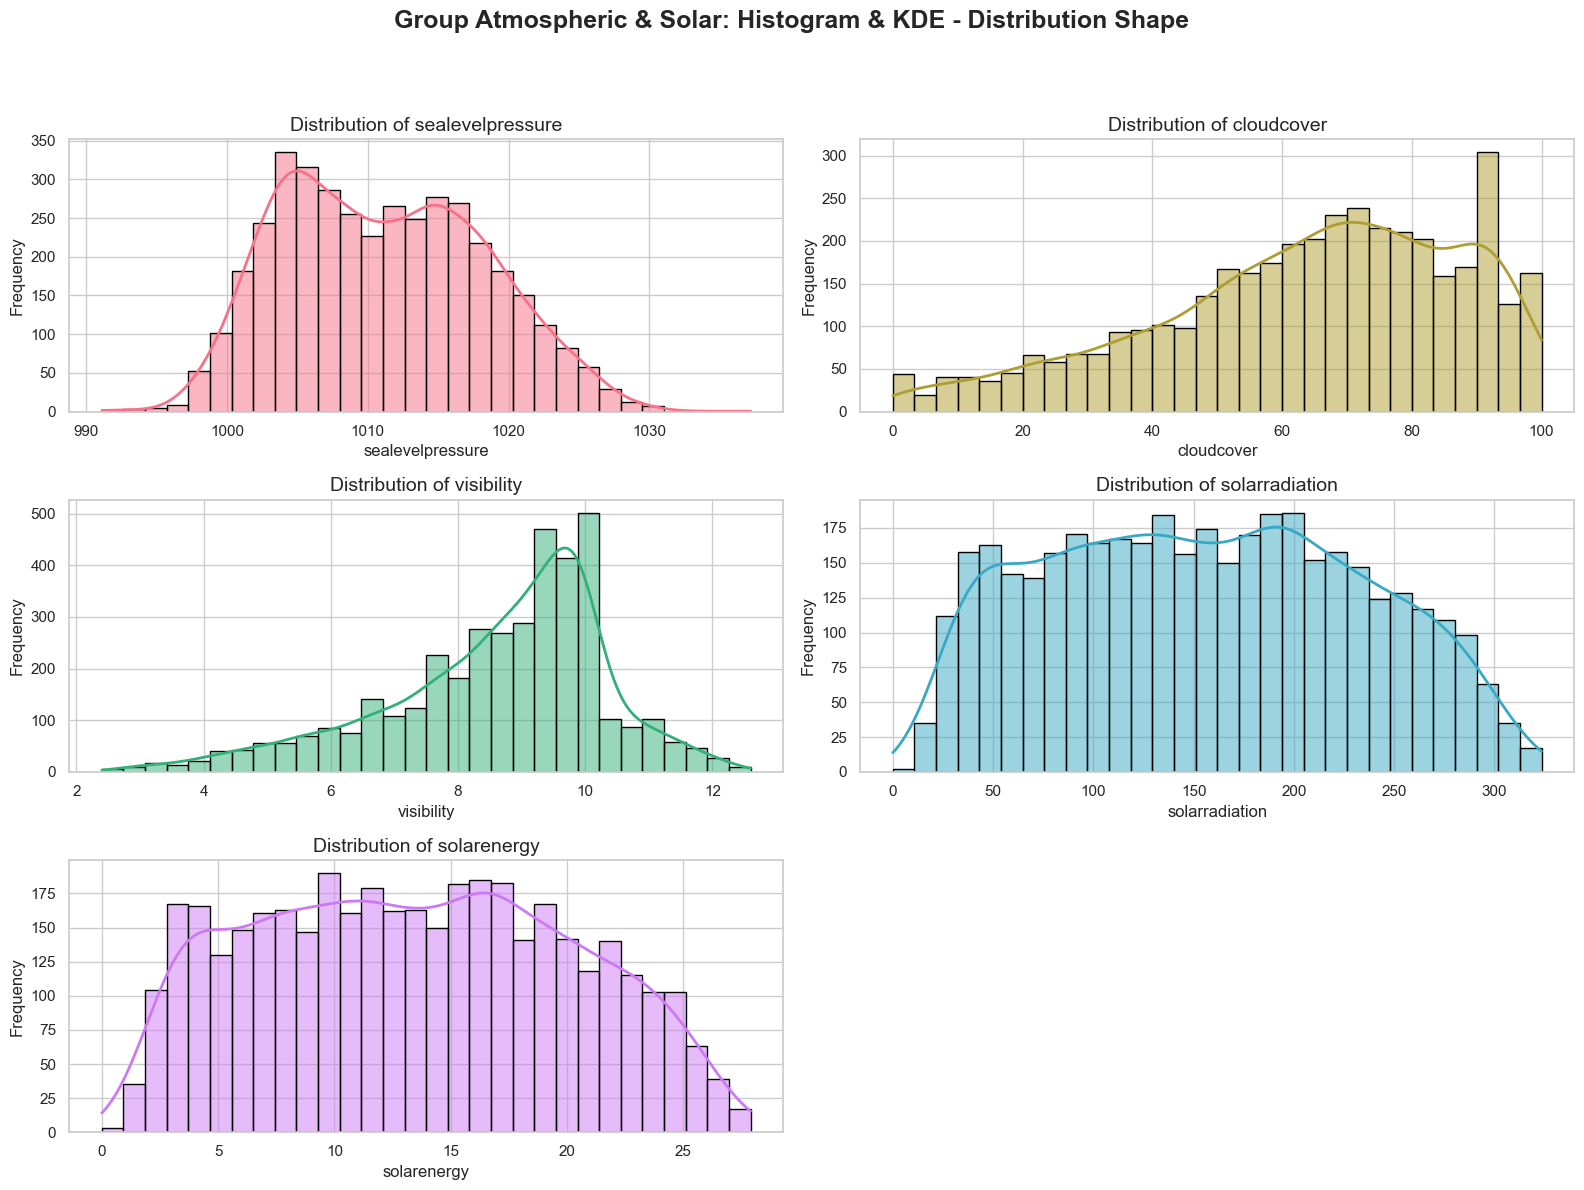

In [79]:
group_name = 'Atmospheric & Solar'
features = ['sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy']
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

colors = sns.color_palette("husl", n_colors=n_features)

plt.rcParams['figure.figsize'] = (16, 4 * n_rows)

fig_hist, axes_hist = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
fig_hist.suptitle(f'Group {group_name}: Histogram & KDE - Distribution Shape', 
                  fontsize=18, fontweight='bold', y=1.02)
axes_hist = axes_hist.flatten() 

for i, col in enumerate(features):
    if col in data.columns:
        # Sử dụng colors[i] để gán màu riêng biệt và đường KDE màu đen
        sns.histplot(data=data, x=col, kde=True, ax=axes_hist[i], 
                     color=colors[i], 
                     edgecolor='black', 
                     bins=30, 
                     line_kws={'lw': 2, 'color': 'black'})
        axes_hist[i].set_title(f'Distribution of {col}', fontsize=14)
        axes_hist[i].set_ylabel('Frequency', fontsize=12)

for j in range(i + 1, n_rows * n_cols):
    if j < len(axes_hist):
        fig_hist.delaxes(axes_hist[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

- The $sealevelpressure$ distribution is near-symmetric and resembles a normal curve, centered around 1010 to 1015 units. Conversely, $cloudcover$ is clearly negatively (left) skewed, with the highest frequency concentrated at high values ($80\%$ to $100\%$), meaning skies are predominantly cloudy.

- The $visibility$ distribution is heavily negatively skewed and features a distinct spike at the maximum measured value of $\mathbf{10}$ units. This suggests the data is limited by an upper bound, and visibility is at or near its maximum most of the time.

- Finally, both $solarradiation$ and $solarenergy$ distributions are broad and relatively symmetric (platykurtic). They lack a sharp peak, indicating that energy values are widely and somewhat uniformly spread across a large range (roughly 50 to 250 units), meaning medium and high energy days occur with similar frequency.

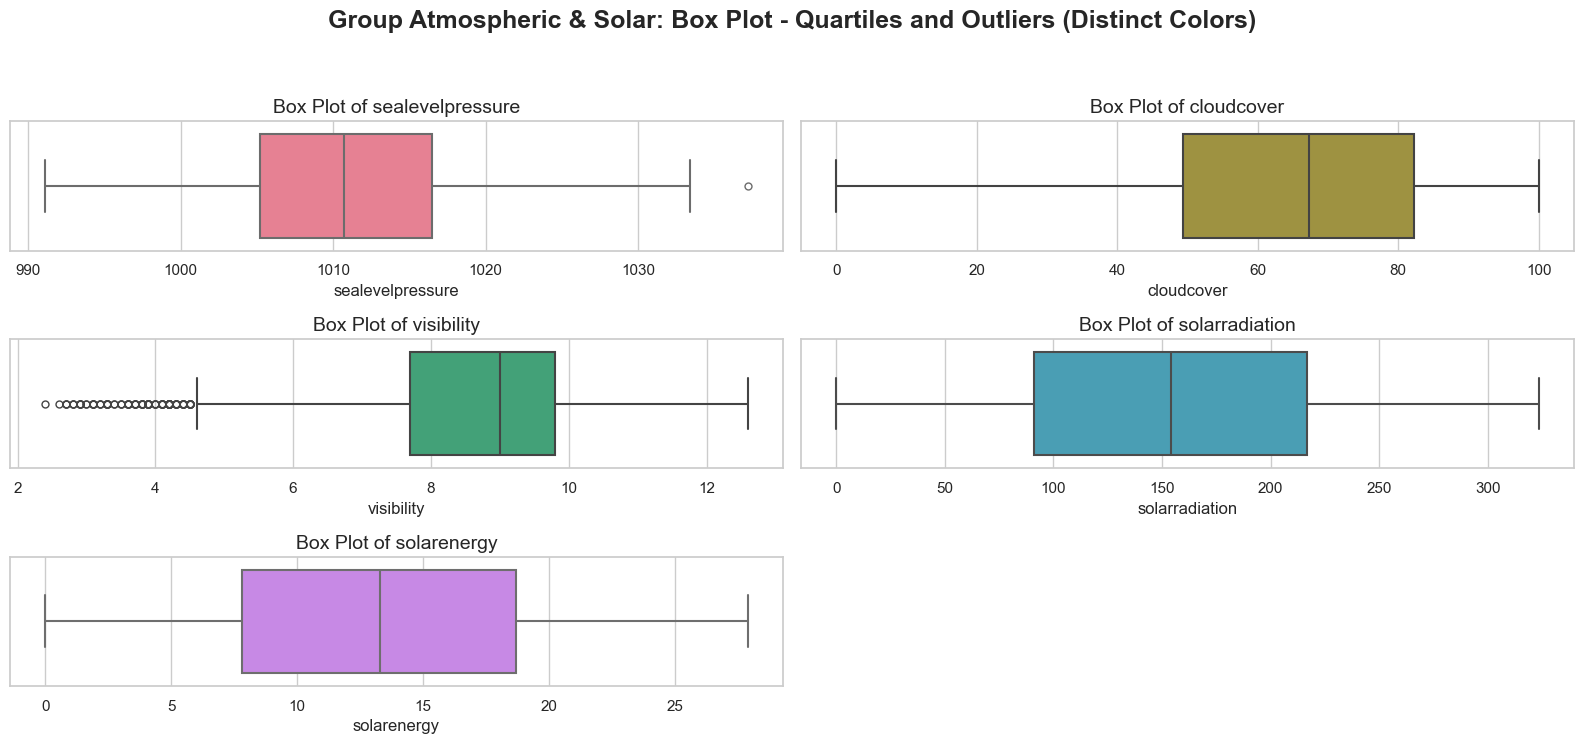

In [80]:
group_name = 'Atmospheric & Solar'
features = ['sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy']
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

colors = sns.color_palette("husl", n_colors=n_features)

plt.rcParams['figure.figsize'] = (16, 2.5 * n_rows)

fig_box, axes_box = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
fig_box.suptitle(f'Group {group_name}: Box Plot - Quartiles and Outliers (Distinct Colors)', 
                 fontsize=18, fontweight='bold', y=1.02)
axes_box = axes_box.flatten() 

for i, col in enumerate(features):
    if col in data.columns:
        # Use distinct color for each box plot
        sns.boxplot(data=data, x=col, ax=axes_box[i], 
                    color=colors[i], 
                    orient='h', fliersize=5, linewidth=1.5)
        axes_box[i].set_title(f'Box Plot of {col}', fontsize=14)
        axes_box[i].set_ylabel('')

# Hide any extra subplots in the last row
for j in range(i + 1, n_rows * n_cols):
    if j < len(axes_box):
        fig_box.delaxes(axes_box[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.show()

- The $sealevelpressure$ variable has a median centered near the middle of the box, indicating a highly symmetric distribution. The IQR box is relatively tight (spanning approximately 1008 to 1018), showing a concentrated distribution of pressure values. Only a single outlier is present on the high-pressure side.

- In contrast, $cloudcover$ has its IQR box situated entirely on the high-value side (roughly $60\%$ to $85\%$), with the median clearly shifted to the right, confirming the strong negative (left) skew observed earlier. The wide IQR suggests substantial variability in cloud coverage, even at high levels.

- Both $solarradiation$ and $solarenergy$ feature wide IQR boxes with the medians positioned close to the center, indicating relative symmetry and a large dispersion of daily solar energy values. Notably, neither variable displays clear outliers, suggesting that extremely anomalous radiation or energy values are not present in the dataset.

- The $visibility$ variable displays a unique pattern: its IQR box (the middle $50\%$ of data) is located at the highest values (roughly $8$ to $10$ units), with the median strongly biased toward the maximum value. This confirms the strong negative skew. The most prominent feature is the presence of a long chain of outliers spanning from approximately 2 to 6 units. These outliers represent the rare days when visibility is significantly reduced, likely due to fog, haze, or heavy rain.

**B. CATEGORICAL VARIABLES**

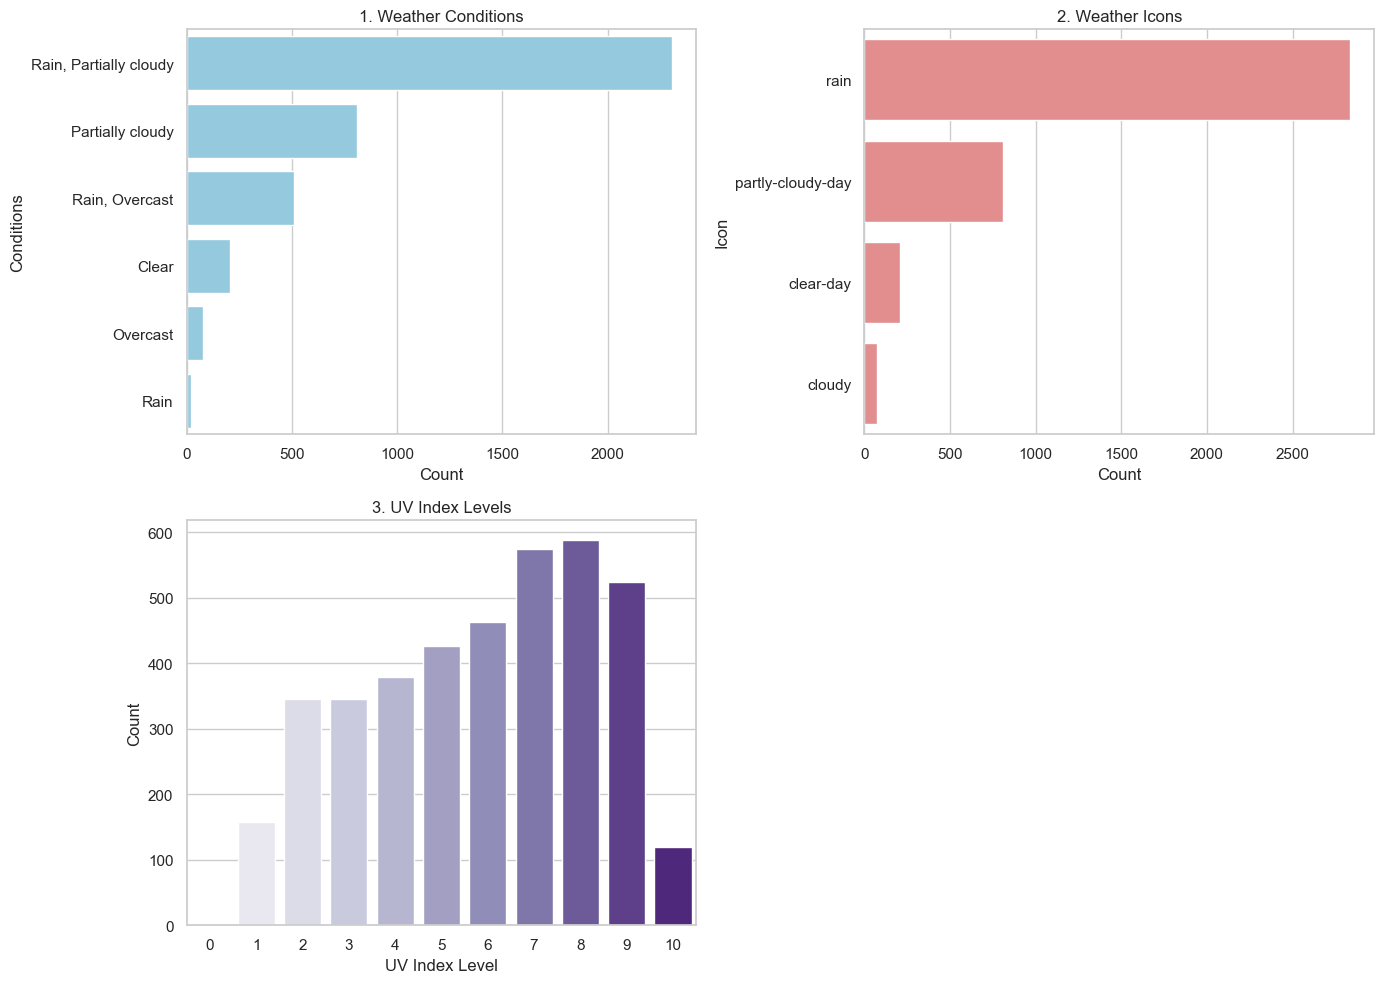

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.figure(figsize=(14, 10))

# --- 1️⃣ Weather Conditions (Countplot) ---
plt.subplot(2, 2, 1) # Position 1 for compact layout
order_cond = df_daily['conditions'].value_counts().index
sns.countplot(
    y='conditions',
    data=df_daily,
    order=order_cond,
    color='skyblue'
)
plt.title("1. Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Conditions")

# --- 2️⃣ Weather Icons (Countplot) ---
plt.subplot(2, 2, 2)
order_icon = df_daily['icon'].value_counts().index
sns.countplot(
    y='icon',
    data=df_daily,
    order=order_icon,
    color='lightcoral'
)
plt.title("2. Weather Icons")
plt.xlabel("Count")
plt.ylabel("Icon")

# --- 3️⃣ UV Index Levels ---
plt.subplot(2, 2, 3)
order_uv = sorted(df_daily['uvindex'].dropna().unique())
colors_uv = sns.color_palette("Purples", len(order_uv))
sns.countplot(
    x='uvindex',
    data=df_daily,
    order=order_uv,
    palette=colors_uv,
    hue='uvindex', 
    legend=False 
)
plt.title("3. UV Index Levels")
plt.xlabel("UV Index Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

- **Weather Conditions:**  
  The most frequent states are *“Partially cloudy”*, *“Overcast”*, and *“Clear”*.  
  This pattern reflects the alternating sunny and cloudy days typical of Hanoi, with few extreme or rare conditions.

- **Weather Icons:**  
  The `icon` variable aligns closely with `conditions`, showing most days as *“partly-cloudy-day”* or *“cloudy”*, while *“rain”* occurs less often but is concentrated during monsoon months.

- **UV Index:**  
  Values range mostly between 4 and 8, with a clear dominance of mid-to-high levels (6–8).  
  This suggests that Hanoi experiences strong sunlight throughout the year, especially during the dry months when cloud cover is lower.

Overall, the categorical variables give a quick qualitative overview of Hanoi’s weather: mostly cloudy-to-clear days, high UV exposure, and rain as the only precipitation type — all consistent with the city’s humid tropical monsoon pattern.


**IV. Correlation Analysis**

### 📊 Correlation Visualization: Explore pairwise relationships within each feature group to identify linear trends, clustering behavior, and potential multicollinearity.




### 📌 1. Function: Correlation Plot for a Variable Group


In [82]:

def plot_group_correlation(df, columns, group_name):
    """
    Plot pairwise correlations for a specific group of variables
    using Seaborn's pairplot.
    """
    sns.set(style="white", font_scale=1.2)

    g = sns.pairplot(
        df[columns],
        diag_kind="kde",
        plot_kws={"alpha": 0.6, "s": 40, "edgecolor": "none"},
        diag_kws={"shade": True}
    )

    g.fig.suptitle(f"Correlation Plot — {group_name}", y=1.02, fontsize=16)
    plt.show()


### 📌 2. Define Variable Groups And Generate Correlation Plots for Each Group


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecat

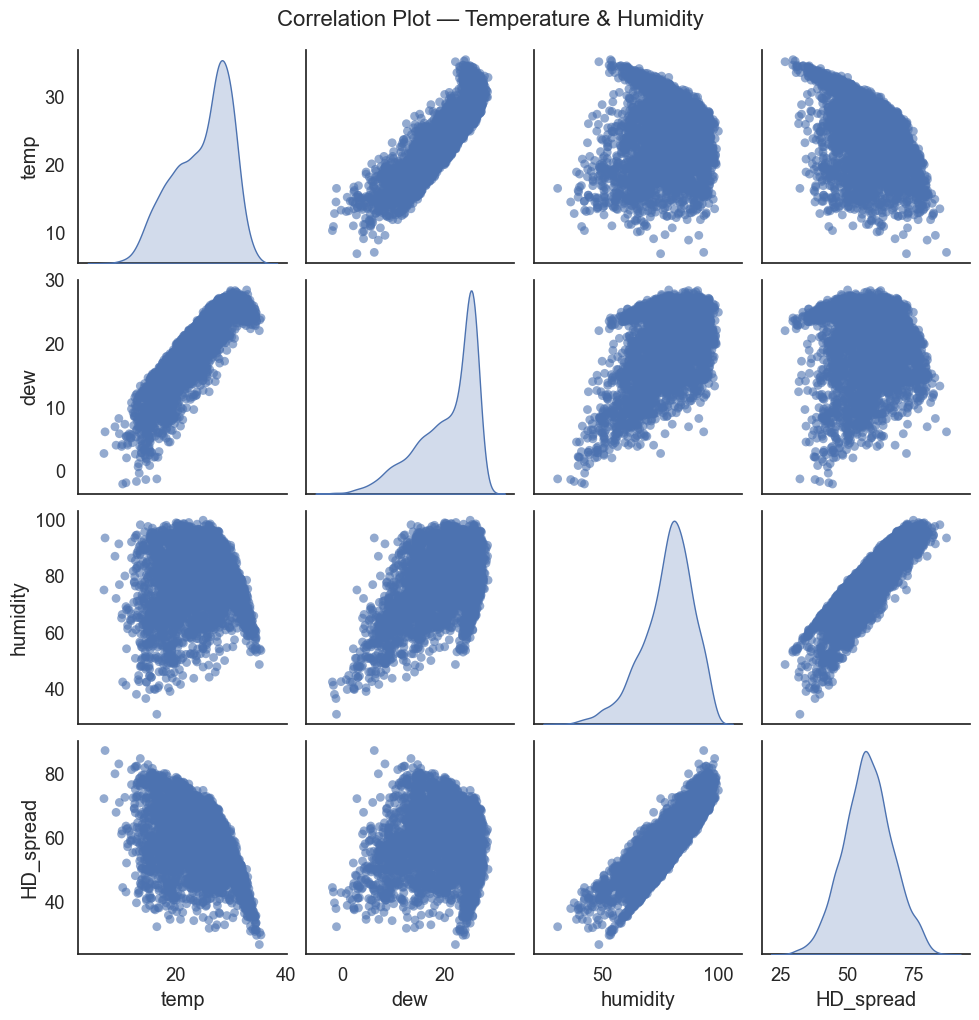

In [83]:
# 1. Temperature & Humidity
df_daily['HD_spread'] = df_daily['humidity'] - df_daily['dew']
group_temp = ["temp", "dew", "humidity", "HD_spread"]
plot_group_correlation(df_daily, group_temp, "Temperature & Humidity")

### **Correlation Analysis — Temperature & Humidity Group**
**`1. Relationship between Temperature (temp) and Dew Point (dew)`**

The plot shows a very strong positive linear correlation between temperature and dew point. The data points form a clear upward-sloping band, indicating that as temperature increases, the dew point also rises. This pattern is physically expected: the dew point reflects the moisture content of the air, and warmer air can hold more water vapor, resulting in higher dew-point values. The dense, low-noise distribution suggests that this relationship is stable and highly predictable, making dew a reliable variable to use in forecasting models that include temperature, and vice versa.

**`2. Relationship between Temperature (temp) and Humidity`**

Temperature and humidity exhibit a noticeably negative correlation. As temperature increases, relative humidity tends to decrease. The scatterplot forms an inverted triangular pattern: at lower temperatures, humidity varies widely, but at higher temperatures, humidity is compressed toward lower values. This matches natural meteorological behavior—warm air is typically drier in relative terms, causing humidity levels to drop as temperature rises.
However, the relationship is not perfectly linear. The spread of points shows significant variability, indicating that many additional weather factors—such as precipitation, wind, and radiation—also influence humidity beyond temperature alone.

**`3. Relationship between Temperature (temp) and HD_spread`**

HD_spread is defined as humidity − dew, representing the gap between relative humidity and dew point. The relationship between temperature and HD_spread is negative: as temperature rises, HD_spread tends to decrease. The downward-sloping distribution suggests that the gap narrows under warmer conditions. This is logical because humidity generally drops with increasing temperature, while the dew point rises with temperature—therefore shrinking the difference between the two. The pattern is consistent and shows relatively low noise, indicating a meaningful and stable correlation.

**`4. Relationship between Dew Point (dew) and Humidity`**

The dew–humidity scatterplot shows a positive correlation, though weaker compared with the temp–dew relationship. In general, higher dew-point values are associated with higher humidity, but the points are widely dispersed rather than forming a tight slope. This reflects the nature of relative humidity, which depends on both moisture content and temperature. Since dew point measures actual moisture while humidity is a temperature-dependent ratio, the relationship is inherently more complex. Still, the overall upward trend confirms that moist air (high dew) tends to coincide with higher relative humidity levels.

**`5. Relationship between Dew Point (dew) and HD_spread`**

Dew point and HD_spread display a relatively strong negative correlation. As dew increases, HD_spread decreases in a clear downward pattern. This is expected because dew point directly appears in the formula HD_spread = humidity − dew; therefore, larger dew-point values naturally reduce the resulting difference. The points form a narrow downward band, indicating that the relationship is linear and stable, with limited noise.

**`6. Relationship between Humidity and HD_spread`**

Humidity and HD_spread show the strongest positive correlation within this group, driven by the mathematical structure of the HD_spread formula. Since HD_spread increases directly with humidity, the plot shows a sharply rising trend with very little noise. The points align closely along an upward-sloping line, making this the most tightly coupled pair in the temperature–humidity group. This reflects a direct dependency, not just a meteorological one.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


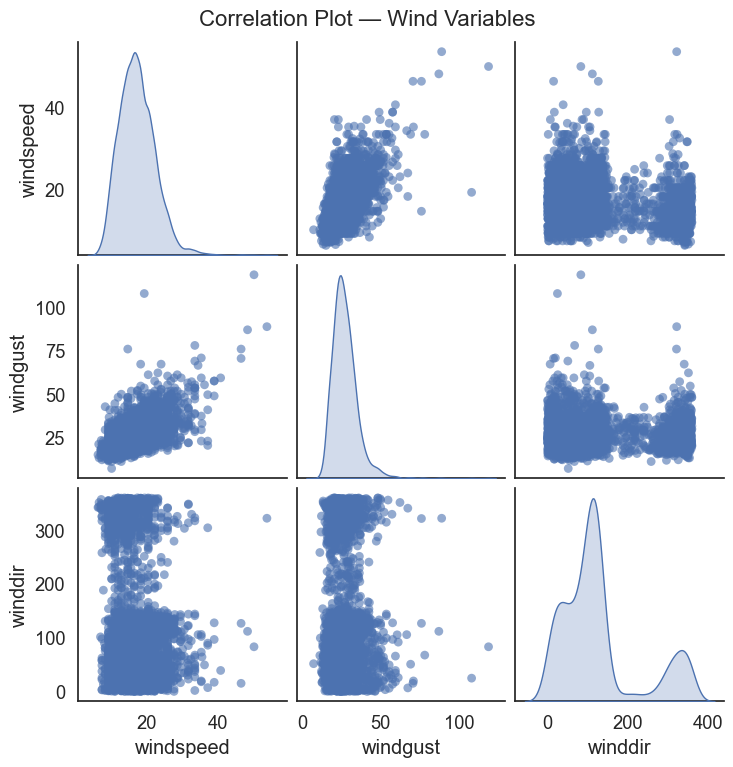

In [84]:
# 2. Wind Factors
group_wind = ["windspeed", "windgust", "winddir"]
plot_group_correlation(df_daily, group_wind, "Wind Variables")

### **Correlation Analysis — Wind Variables**
**`1. Relationship between Windspeed and Windgust`**

The plot shows a clear positive correlation between windspeed and windgust. Most data points form an upward-sloping cluster, indicating that stronger sustained winds generally accompany stronger gusts. This relationship is expected, as gusts represent short-lived increases above the baseline wind speed. However, the point cloud becomes more dispersed at higher values, suggesting that gust intensity becomes more variable as windspeed increases. A few extreme gusts appear well above the main cluster, showing that unusually strong gust events can occur even when sustained winds are not exceptionally high. Overall, the relationship is strong, though moderately heteroscedastic, and windspeed is a useful predictor for windgust in forecasting models.

**`2. Relationship between Windspeed and Wind Direction (winddir)`**

The scatterplot indicates no clear linear correlation between windspeed and wind direction. Instead of forming a continuous trend, the points cluster into several distinct vertical bands, corresponding to prevailing wind directions. Within each directional band, windspeed values vary across a broad range, meaning that specific wind directions do not consistently produce higher or lower wind speeds. This pattern reflects the categorical nature of wind direction and the influence of regional atmospheric patterns that cause wind to originate predominantly from a few dominant directions. Because wind direction is circular, this relationship cannot be evaluated with standard linear correlation, and interpretation must rely on directional clustering rather than slope or linear structure.

**`3. Relationship between Windgust and Wind Direction (winddir)`**

The windgust–winddir plot follows a pattern similar to the windspeed–winddir relationship, showing distinct directional clusters rather than a linear association. Gust values vary widely within each directional band, with some directions exhibiting a higher frequency of strong gusts. This suggests that certain wind directions correspond to weather regimes that produce more turbulent or unstable wind conditions. As with windspeed, the circular nature of wind direction and the multimodal distribution of winddir make linear correlation inappropriate. The key insight is that gust behavior differs depending on directional airflow patterns, but not in a way that forms a traditional numeric trend.

**`4. Distribution of Windspeed`**

The marginal density plot for windspeed shows a right-skewed distribution, with most values concentrated in the low-to-moderate range. As windspeed increases, observations become less frequent, indicating that strong sustained winds are relatively rare. This distribution is typical of environmental wind data, where calm or moderate winds occur most of the time, with occasional periods of stronger flow.

**`5. Distribution of Windgust`**

Windgust exhibits an even more pronounced right-skewed distribution compared to windspeed. The density peaks at low gust values but extends into a long tail of high-intensity gusts. This pattern reflects the inherently sporadic and extreme nature of gusts, which arise from short-term atmospheric instability. The presence of several outliers suggests that rare but intense gust events occur and may require special treatment in modeling.

**`6. Distribution of Wind Direction (winddir)`**

The wind direction distribution is strongly multimodal, showing two or more peaks rather than a uniform spread across 0°–360°. This indicates that winds predominantly come from certain directional sectors, reflecting regional climatological patterns such as seasonal monsoon flows or topographic channeling. The multimodal structure explains the banded appearance in the windspeed–winddir and windgust–winddir scatterplots. Because direction is circular, values near 0° and 360° represent the same direction, and interpretation should account for this periodicity.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


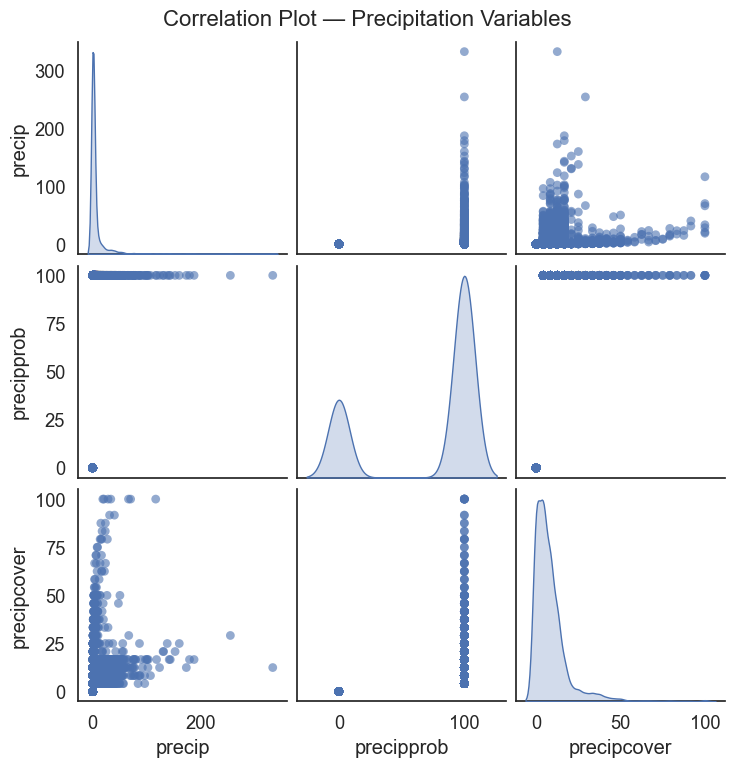

In [85]:
# 3. Precipitation Variables
group_precip = ["precip", "precipprob", "precipcover"]
plot_group_correlation(df_daily, group_precip, "Precipitation Variables")

### Correlation Analysis — Precipitation Variables
**`1. Relationship between Precipitation Amount (precip) and Precipitation Probability (precipprob)`**

The plot shows a weak and highly non-linear relationship between precipitation amount and precipitation probability. While high precipitation probabilities (near 100%) often coincide with non-zero precipitation values, the scatter is extremely concentrated and irregular: many points show high probabilities even when the actual precipitation is low or zero. This reflects the nature of forecast probability, which estimates the likelihood of rain rather than its intensity. As a result, a high precipprob does not guarantee heavy rainfall, and light precipitation can occur even at moderate probabilities. A few extreme precipitation values appear well above the core cluster, showing rare heavy-rain events. Overall, the correlation is weak, with the probability measure offering limited predictive power regarding actual rainfall intensity.

**`2. Relationship between Precipitation Amount (precip) and Precipitation Coverage (precipcover)`**

The precip–precipcover scatterplot reveals a broad, loosely positive trend: higher precipitation amounts tend to be associated with larger precipitation coverage values. However, the relationship is highly scattered and far from linear. Most data points cluster near low precipcover values even when moderate precipitation amounts occur, indicating that widespread rain is relatively uncommon. Conversely, some high precipcover values occur with low precipitation amounts, reflecting situations where rain is widespread but light. The plot also includes several heavy-rain outliers that extend far above the main cluster. Overall, the trend is directionally positive but strongly diffuse due to the complexity of how rainfall spatial coverage relates to actual volume.

**`3. Relationship between Precipitation Probability (precipprob) and Precipitation Coverage (precipcover)`**

The plot displays a curious pattern dominated by discrete bands: precipprob takes on only a few distinct values, with the majority of observations concentrated around 100%. Because precipprob is likely derived from forecast data that uses discrete probability levels, it does not vary continuously. As a result, the scatter appears as vertical lines rather than a smooth spread. Within each band, precipcover varies considerably, demonstrating that probability of precipitation and actual spatial coverage are not strongly aligned. Even when precipprob is high, precipcover ranges from very low to moderate levels; conversely, low probabilities correspond to very low coverage values. The overall association is weak, influenced more by the discrete nature of precipprob than by meteorological structure.

**`4. Distribution of Precipitation Amount (precip)`**

The distribution of precip is extremely right-skewed. A large majority of observations fall near zero, indicating that rainfall is infrequent or very light on most days. The tail extends sharply toward high values, showing occasional heavy-rain events that are rare but meteorologically significant. This type of distribution is typical of precipitation variables in many climates, where rain events are sparse and unevenly distributed.

**`5. Distribution of Precipitation Probability (precipprob)`**

The marginal density of precipprob is distinctly multimodal. There is a peak at low probability values and a much stronger peak near 100%, with relatively little density in between. This reflects the way precipitation probability is often reported: many forecasts categorize the likelihood into broad and discrete levels (e.g., 0%, 20–30%, or 100%). The resulting distribution is dominated by certainty levels (either very likely or very unlikely), rather than a continuous range of probabilities.

**`6. Distribution of Precipitation Coverage (precipcover)`**

The distribution of precipcover is right-skewed, with most values concentrated near the low end of the scale. This means that in the majority of cases, precipitation (if it occurs) is limited in spatial coverage. Larger coverage values do appear but less frequently, suggesting that widespread rainfall events are relatively uncommon. The long tail reflects occasional days where precipitation is more extensive, consistent with major weather systems or storm events.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecat

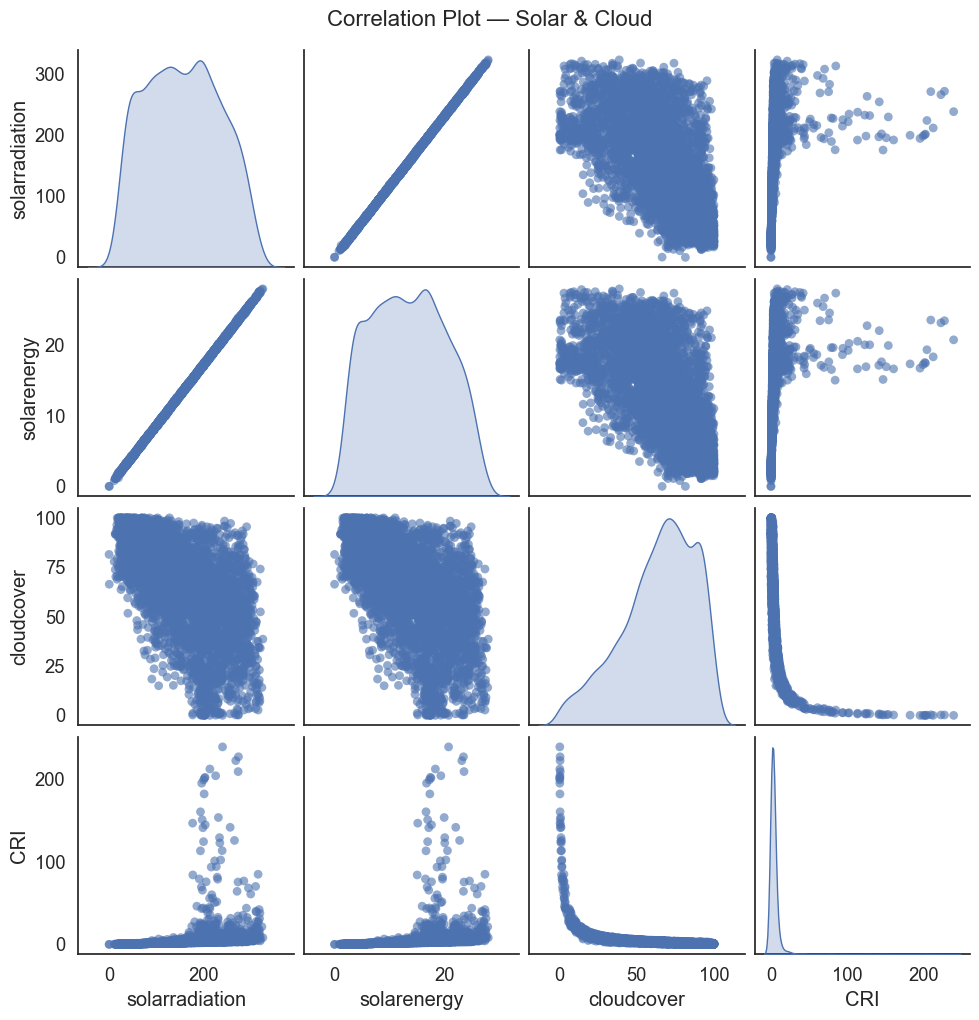

In [86]:
# 4. Solar & Cloud Variables
df_daily['CRI'] = df_daily['solarradiation'] / (df_daily['cloudcover'] + 1)
group_solar = ["solarradiation", "solarenergy", "cloudcover", "CRI"]
plot_group_correlation(df_daily, group_solar, "Solar & Cloud")

### Correlation Interpretation — Solar & Cloud Variables (Numbered Paragraphs)
**`1. Relationship between Solar Radiation and Solar Energy`**

Solar radiation and solar energy display an almost perfect linear correlation, forming a tight diagonal line across their scatterplot. This indicates that solar energy is essentially a rescaled or accumulated version of solar radiation, meaning the two variables carry nearly identical information. Because of this, they introduce redundancy, and retaining both may not add additional value for modeling. Their density plots also share nearly the same shape, reinforcing the idea that they represent the same underlying solar input.

**`2. Negative Impact of Cloudcover on Solar Variables`**

Cloudcover shows a strong inverse relationship with both solar radiation and solar energy. When cloudcover is low, solar values vary widely and can reach high levels; however, as cloudcover increases, solar radiation and energy collapse rapidly toward zero. This creates a triangular scatter distribution where high solar values only occur under clear-sky or lightly clouded conditions. These patterns are consistent with atmospheric physics: thicker cloud layers block incoming sunlight and drastically reduce solar availability.

**`3. Nonlinear Behavior and Skewness of the CRI Index`**

The CRI variable exhibits a sharply nonlinear pattern due to its formula (solarradiation / (cloudcover + 1)). CRI values are heavily concentrated near zero, but when cloudcover approaches zero and solar radiation is strong, CRI spikes dramatically, forming extreme outliers. As a result, the plots show vertical “towers” of high CRI values at strong solar inputs, and steep curved drops when cloudcover increases. This behavior highlights that CRI is not a general measure of solar–cloud interaction but rather an index that amplifies rare optimal solar conditions.

**`4. Overall Structure and Insights Across the Solar–Cloud Group`**

Taken together, the variables form a clear and physically intuitive structure. Solar radiation and solar energy act as nearly duplicate indicators of solar intensity, cloudcover operates as the dominant limiting factor on solar values, and CRI reflects extreme clear-sky conditions through highly skewed behavior. The relationships suggest that cloudcover is an essential predictive feature, while solar radiation and solar energy are too collinear to be used simultaneously. CRI may add nonlinear information but requires careful handling due to its heavy skewness and extreme sensitivity to low cloudcover.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


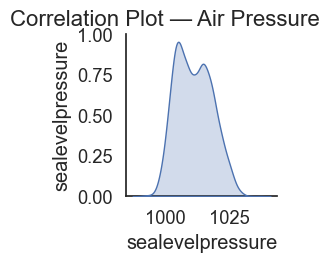

In [87]:
# 5. Pressure
group_pressure = ["sealevelpressure"]
plot_group_correlation(df_daily, group_pressure, "Air Pressure")

### Correlation Interpretation — Air Pressure Variable 
**`1. Distribution and Variability of Sea-Level Pressure`**

The plot shows the distribution of sea-level pressure as a smooth, unimodal curve with a slight secondary peak, indicating that pressure values cluster within a relatively narrow range. Most readings lie between roughly 995 and 1025 hPa, suggesting stable atmospheric conditions with limited extreme fluctuations. The concentration of values around the central region implies that the dataset reflects typical weather patterns rather than storm-heavy or highly variable pressure environments. This narrow spread also means that sea-level pressure contributes limited variance on its own, but its stability may still be useful when combined with other meteorological variables for detecting subtle weather transitions.

**`2. Implications for Correlation and Predictive Modeling`**

Because the plot contains only a single variable, no scatter relationships can be observed directly; however, the tightly clustered distribution suggests that sea-level pressure is likely to show only moderate correlations with other weather indicators. Variables such as precipitation, humidity, and wind can be influenced by pressure changes, but the relatively small variation here means these effects may be weak or nonlinear. In modeling contexts, pressure may still contribute to forecasts of storms or moisture shifts, but it will not be a dominant driver compared with variables like temperature, cloudcover, or dew point.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


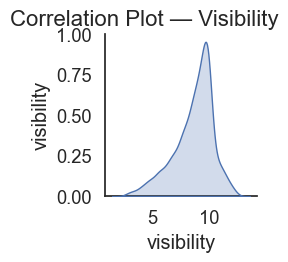

In [88]:
# 6. Visibility
group_visibility = ["visibility"]
plot_group_correlation(df_daily, group_visibility, "Visibility")

### Correlation Interpretation — Visibility Variable 
**`1. Distribution and Variability of Visibility`**

The plot illustrates the distribution of visibility values, showing a smooth, unimodal shape concentrated primarily between approximately 5 and 12 kilometers. The density peaks near the upper portion of this range, indicating that most observations record relatively high visibility under typical atmospheric conditions. The lower tail—extending toward reduced visibility—appears sparse, suggesting that episodes of fog, heavy precipitation, or air pollution are relatively infrequent in the dataset. Overall, the distribution reflects a predominantly clear-air environment with only occasional drops in visibility.

**`2. Implications for Correlation and Predictive Modeling`**

Since the plot contains only a single variable, no direct pairwise relationships can be observed; however, the tight clustering and absence of extreme low-visibility events imply that visibility may show limited linear correlation with other variables such as precipitation, humidity, or cloudcover. When visibility does drop, the change is likely driven by specific weather events (e.g., rain, fog, or high humidity), meaning its correlations with those variables may be nonlinear or event-dependent rather than consistent across the entire dataset. In predictive modeling, visibility may therefore serve more effectively as an indicator of unusual or transitional weather conditions rather than a variable that provides continuous explanatory power.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


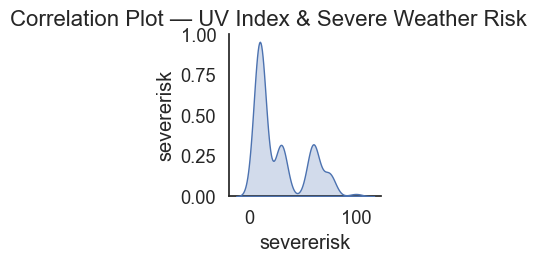

In [89]:
# 7. UV Index & Severe Weather Risk
group_uv = ["uvindex", "severerisk"]
plot_group_correlation(df_daily, group_uv, "UV Index & Severe Weather Risk")

### Correlation Interpretation — UV Index & Severe Weather Risk
**`1. Distribution and Variability of Severe Weather Risk`**

The plot displays a multi-modal distribution for the severe weather risk variable, showing several distinct peaks rather than a single smooth curve. Most values cluster near the very low end of the scale, indicating that severe weather events are relatively rare in the dataset. Beyond this dense region, there are smaller bumps at moderate and higher risk levels, suggesting occasional spikes in severe weather probability. The presence of multiple modes implies that the data may reflect a mixture of different weather regimes—for example, periods of stable conditions interspersed with isolated storms or high-risk days.

**`2. Implications for Correlation and Predictive Modeling`**

Because this plot contains only one variable, we cannot directly observe its relationships with UV index or other meteorological features. However, the uneven, multi-peaked distribution suggests that severe weather risk is likely influenced by a combination of factors rather than a single dominant driver. Variables such as precipitation probability, cloudcover, humidity, and wind gusts may all contribute in different ways across different regimes. The rarity of high-risk values also means that its correlations with most continuous weather variables may appear weak when measured across the entire dataset. From a modeling perspective, severe weather risk is better treated as an event-based or classification-oriented target rather than a continuously varying predictor.

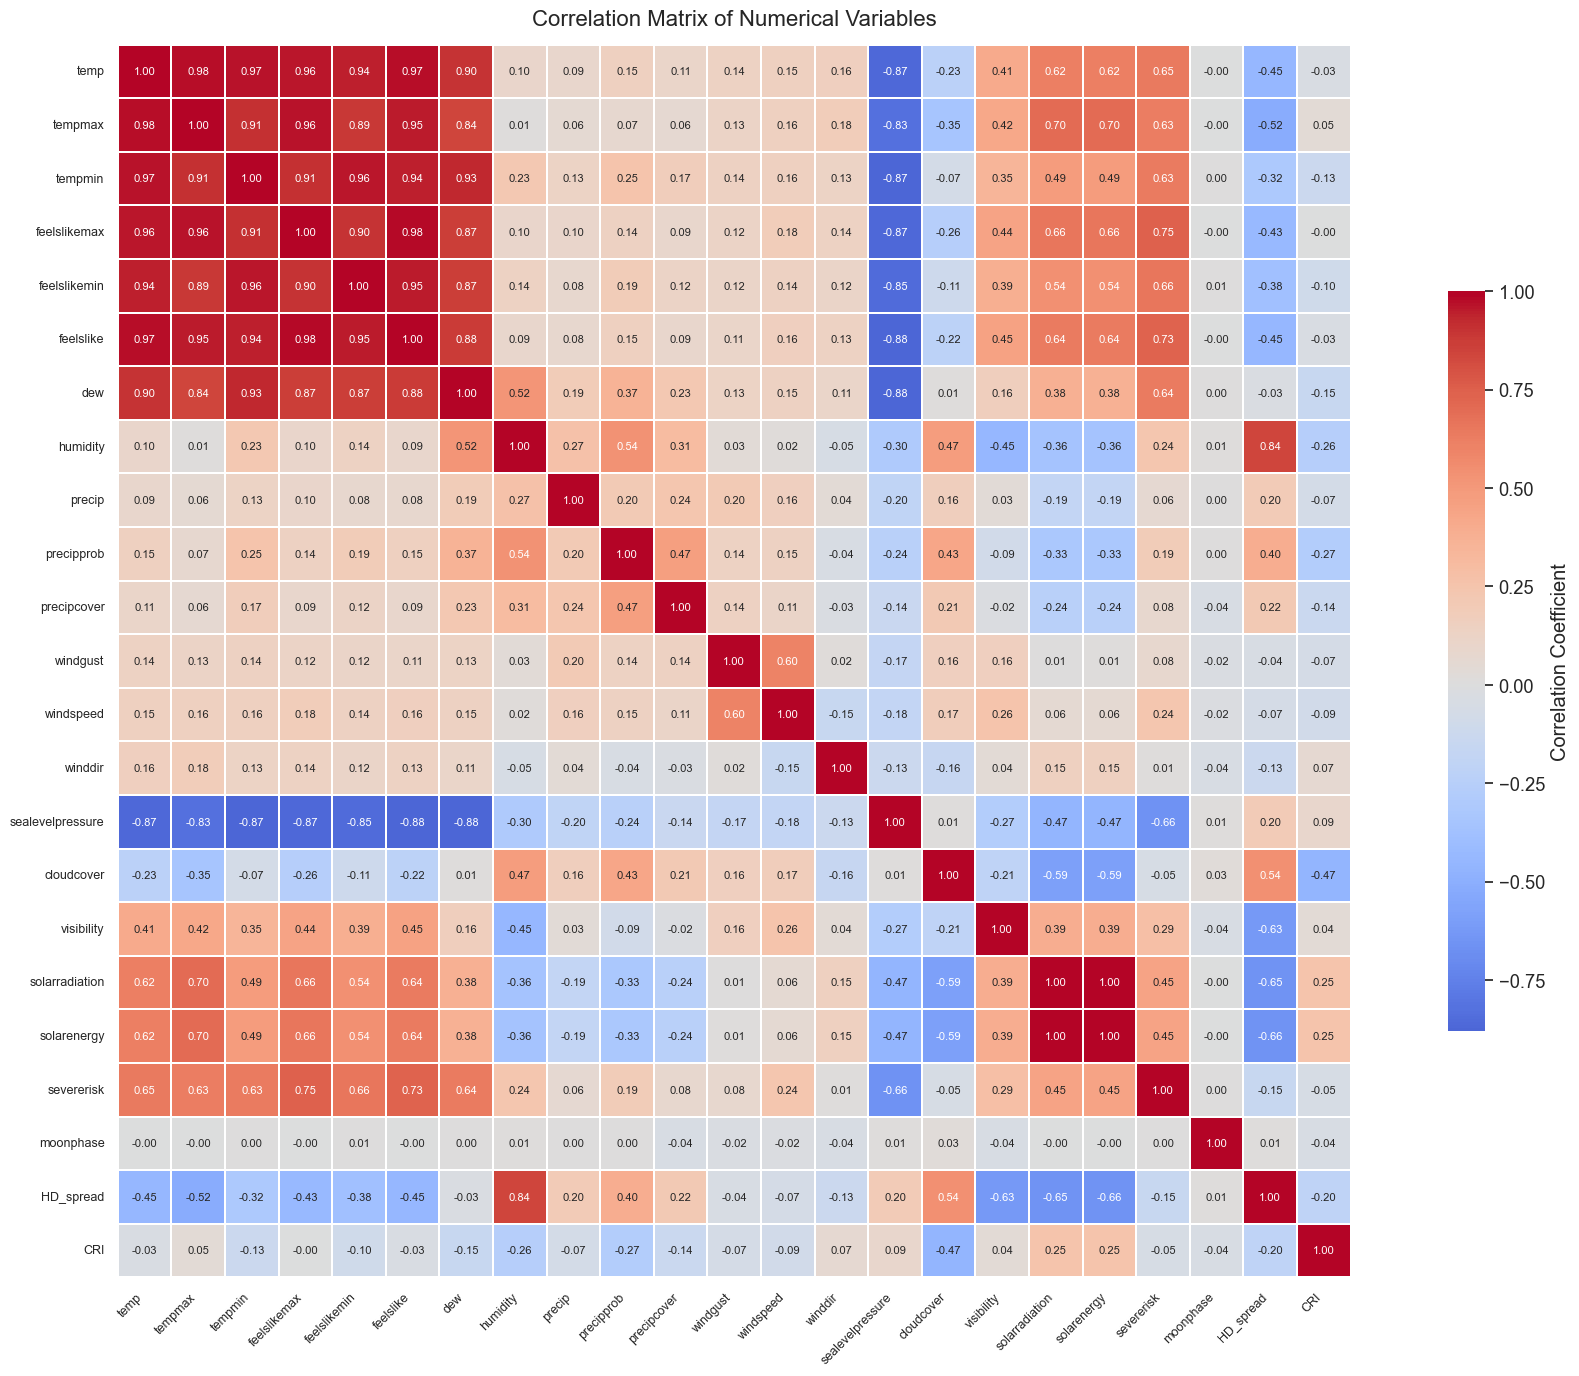

In [90]:
# ===== 1. Select numerical features =====
num_df = df_daily.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr()

# Move 'temp' to the first column/row if it exists
if 'temp' in corr_matrix.columns:
    cols = ['temp'] + [col for col in corr_matrix.columns if col != 'temp']
    corr_matrix = corr_matrix.loc[cols, cols]

# ===== 2. Plot correlation heatmap =====
plt.figure(figsize=(20, 14))  # Larger figure for readability

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 8},      # Smaller annotation size to avoid overlap
    linewidths=0.3,              # Add grid lines for clarity
    cbar_kws={'shrink': 0.6, 'label': 'Correlation Coefficient'}
)

# Rotate axis labels for better visibility
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16, pad=14)
plt.tight_layout()
plt.show()


- When looking at the correlation matrix, the first thing that stands out is how strongly the temperature-related variables move together.
`temp`, `tempmax`, `tempmin`, and all the “feels like” metrics are almost perfectly correlated — usually above 0.95. This is expected, since these measurements all describe the same underlying thermal behavior.
**Because they are nearly duplicates, they introduce strong redundancy and multicollinearity, so it is better to remove some of them or keep only one representative (e.g., `temp`) during feature engineering.**

- Another clear relationship is the strong **negative correlation between air pressure and temperature** (around −0.87). This aligns well with Hanoi’s climate: hot, humid days typically come with lower pressure, while cooler and more stable periods are associated with higher pressure. For this reason, sealevelpressure appears to be a genuinely informative feature that can help capture seasonal shifts or pre-storm pressure drops.

- The rainfall-related variables — `precip`, `precipprob`, and `precipcover` — are also highly correlated with each other (0.7–1.0), which is perfectly reasonable given that they represent different aspects of rain occurrence and intensity.
Their correlation with temperature is fairly low (0.1–0.2), which matches local weather patterns: in Hanoi, heavy rain does not necessarily mean cooler temperatures, especially during tropical summer storms. These features are still useful but somewhat redundant within their own group.

- The solar and cloud-related features behave exactly as expected. `solarradiation` and `solarenergy` are nearly identical (corr ≈ 0.99) and both show strong positive correlation with temperature and strong negative correlation with `cloudcover`. This reflects natural physics — clear skies lead to higher sunlight exposure, which raises temperatures while reducing cloud cover. This confirms that the dataset captures realistic day-to-day weather behavior.
- Wind speed and gusts show a moderate correlation (around 0.8), meaning stronger winds generally produce stronger gusts. Their relationship with temperature is minimal, which makes sense because wind in Hanoi is driven more by monsoon patterns than day-to-day temperature changes.
`visibility` has a weak negative correlation with humidity and cloud cover, consistent with foggy or hazy conditions when the air is moisture-heavy — common during humid months.

- A few features stand out as less useful. `moonphase` shows no meaningful correlation with any variable, which is expected since it has no physical connection to temperature or weather behavior. `severerisk` shows moderate correlation with temperature and solar variables, likely reflecting the data provider’s internal scoring method rather than true meteorological causation.

Overall, the correlation struct
- Overall, the correlations make sense and match how Hanoi’s weather behaves in reality. The high correlations between temperature variables aren’t an issue — they simply confirm internal consistency. The mix of positive and negative relationships among radiation, humidity, cloud cover, and pressure paint a very realistic picture of the local climate.

- That said, when several features are highly correlated **with each other**, it is important to avoid redundancy in modeling.
For example, since `solarradiation` and `solarenergy` are nearly identical, and the rainfall variables (`precip`, `precipprob`, `precipcover`) strongly overlap, it is more effective to **keep only one representative variable from each group, or to combine them into a composite index** (e.g., a solar exposure score or precipitation index).
This reduces multicollinearity, simplifies the model, and makes the learned relationships easier to interpret, while still preserving the core weather patterns captured in the data.